Exploratory Data Analysis on the Airbnb data

In [476]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math 
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from scipy.stats import chi2
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf

In [477]:
# Load the dataset
df = pd.read_csv('../data/processed/AB_NYC_2019_working_table.csv')

# ℹ️ Display basic information about the dataset
print(f"📐 Dataset shape (rows, columns): {df.shape}")
print("\n📊 Dataset Info:")
print(df.info())

📐 Dataset shape (rows, columns): (38843, 11)

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38843 entries, 0 to 38842
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             38843 non-null  object 
 1   neighbourhood                   38843 non-null  object 
 2   latitude                        38843 non-null  float64
 3   longitude                       38843 non-null  float64
 4   room_type                       38843 non-null  object 
 5   price                           38843 non-null  int64  
 6   minimum_nights                  38843 non-null  int64  
 7   number_of_reviews               38843 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  38843 non-null  int64  
 10  availability_365                38843 non-null  int64  
dtypes: float64(3), int64(5), object

In [478]:
# ❓ Checking for missing values to identify data quality issues
print("\n🔍 Missing values per column:")
print(df.isnull().sum())


🔍 Missing values per column:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [479]:
# 📈 Descriptive statistics like mean, std deviation, min, max, etc.
print("\n📋 Statistical Summary:")
print(df.describe())


📋 Statistical Summary:
           latitude     longitude         price  minimum_nights  \
count  38843.000000  38843.000000  38843.000000    38843.000000   
mean      40.728134    -73.951148    142.317947        5.868059   
std        0.054990      0.046695    196.945624       17.384784   
min       40.506410    -74.244420      0.000000        1.000000   
25%       40.688640    -73.982470     69.000000        1.000000   
50%       40.721710    -73.954800    101.000000        2.000000   
75%       40.762990    -73.935020    170.000000        4.000000   
max       40.913060    -73.712990  10000.000000     1250.000000   

       number_of_reviews  reviews_per_month  calculated_host_listings_count  \
count       38843.000000       38843.000000                    38843.000000   
mean           29.297557           1.373221                        5.164457   
std            48.186374           1.680442                       26.295665   
min             1.000000           0.010000             

1 - Exploratory Data Analysis

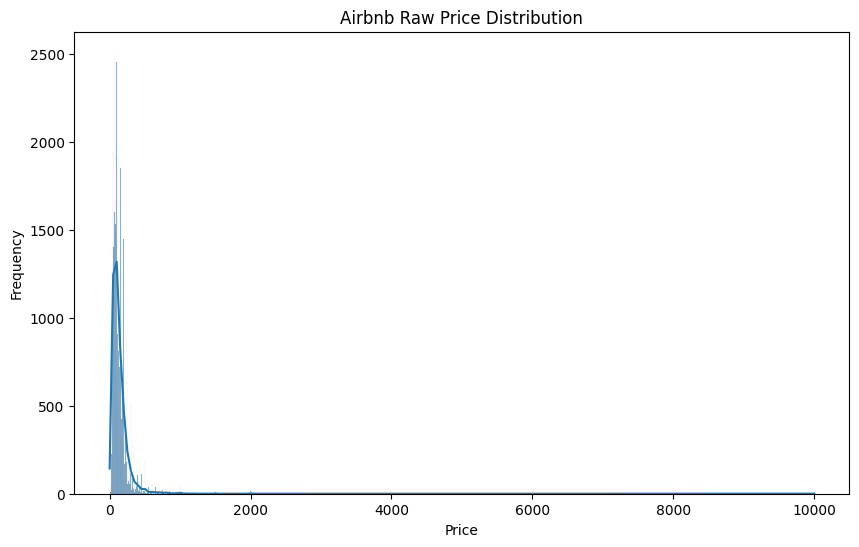

📊 Plotted Airbnb Raw price distribution.


In [480]:
#-----------------------------#
# a) Target Variable Analysis #
#-----------------------------#

# 💰 Visualizing the distribution of Airbnb prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Airbnb Raw Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

print("📊 Plotted Airbnb Raw price distribution.")

In [481]:
from scipy.stats import skew, kurtosis

#Visualise the log price distribution using the Skewness and kurtosis
df_eda= df.copy()

df_eda["price"]=(
    df_eda["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

#Invalid prices removal
df_eda=df_eda[df_eda["price"]>0].copy()

#Create Log Price
df_eda["log_price"]=np.log1p(df_eda["price"])

#Summary statistics
price_summary = df_eda[["price", "log_price"]].describe().T
price_summary["skewness"] = df_eda[["price", "log_price"]].apply(skew)
price_summary["kurtosis"] = df_eda[["price", "log_price"]].apply(kurtosis)


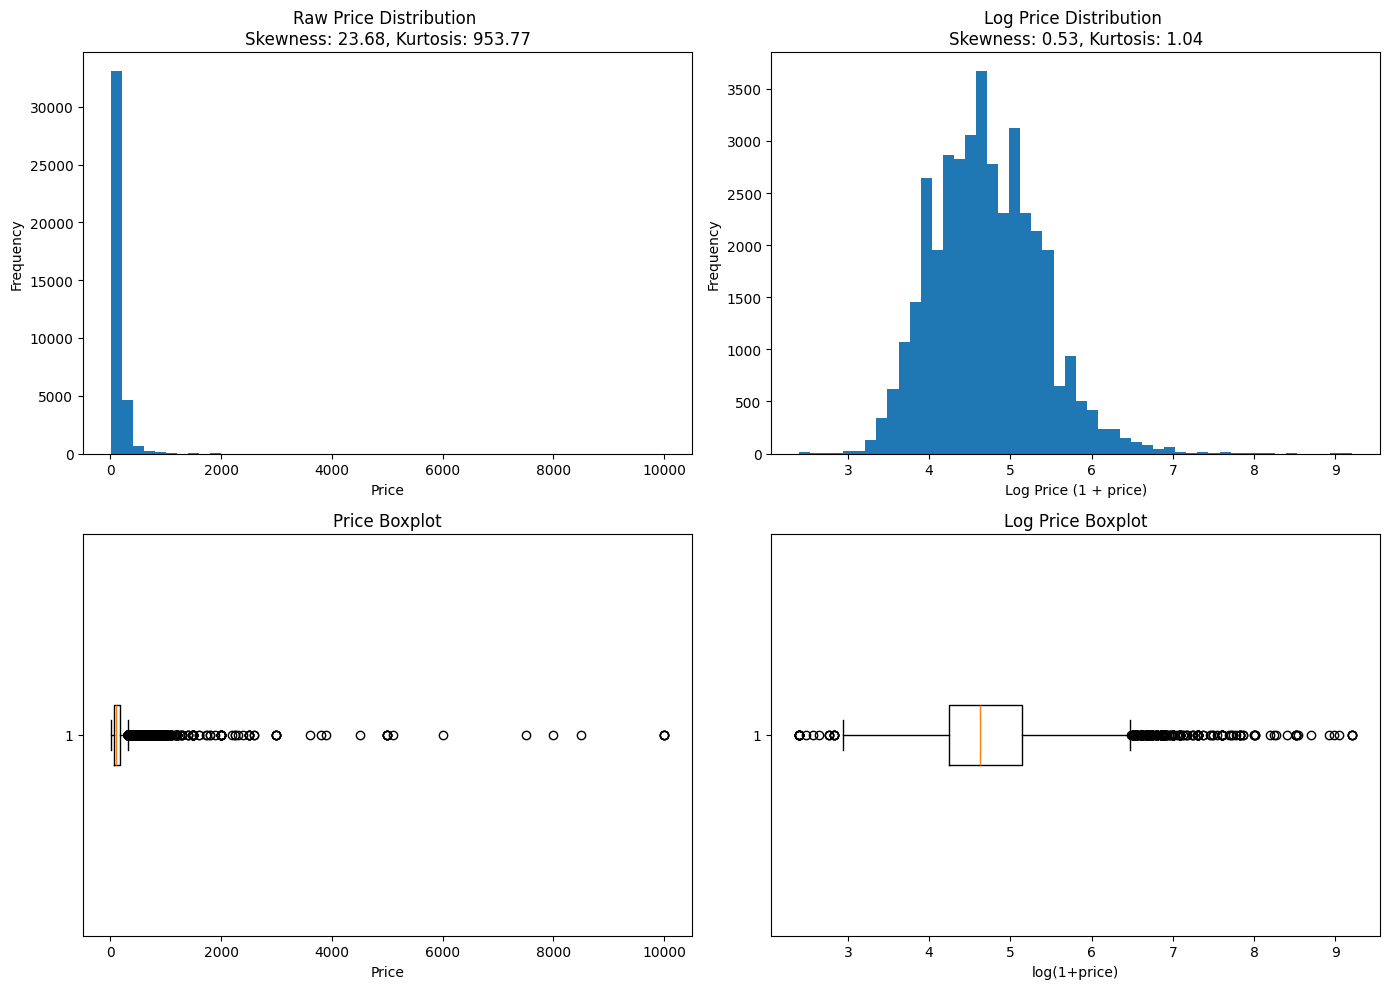

In [482]:
#create 4 plots

#Statistics Calculation
raw_skew= skew(df_eda["price"])
log_skew= skew(df_eda["log_price"])

raw_kurt= kurtosis(df_eda["price"])
log_kurt= kurtosis(df_eda["log_price"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#1.raw price histogram
axes[0,0].hist(df_eda["price"], bins=50)
axes[0,0].set_title(f"Raw Price Distribution \nSkewness: {raw_skew:.2f}, Kurtosis: {raw_kurt:.2f}")
axes[0,0].set_xlabel("Price")
axes[0,0].set_ylabel("Frequency")

#2.log price histogram
axes[0,1].hist(df_eda["log_price"], bins=50)
axes[0,1].set_title(f"Log Price Distribution \nSkewness: {log_skew:.2f}, Kurtosis: {log_kurt:.2f}")
axes[0,1].set_xlabel("Log Price (1 + price)")
axes[0,1].set_ylabel("Frequency")

#2.Raw price boxplot
axes[1,0].boxplot(df_eda["price"], vert=False)
axes[1,0].set_title("Price Boxplot")
axes[1,0].set_xlabel("Price")


#2.log price boxplot
axes[1,1].boxplot(df_eda["log_price"], vert=False)
axes[1,1].set_title("Log Price Boxplot")
axes[1,1].set_xlabel("log(1+price)")

plt.tight_layout()
plt.show()

In [483]:
# We can see that the raw price distribution in highly skewed to the right indicating a smaller skewness(alpha) at 23.68 compared to a higher kurtosis(beta) at 953.77, meaning that prices 
# are extremely right-skewed and dominated by severe outliers.
 
# After applying log transformation, both measure improve substantially, with Skewness(alpha) coming at 0.53 and Kurtosis coming at 1.04, showing that log_price is much closer to a 
# normal-like distribution. Thefore, log_price is a more appropriate modelling target because it reduces the influence of extreme prices, while stabilising the variance and allowing
# the model to learn pricing patterns more effectively.

C:\Users\Mestr\AppData\Local\Temp\ipykernel_13940\632326679.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='room_type', ax=axes[0], palette='viridis')
C:\Users\Mestr\AppData\Local\Temp\ipykernel_13940\632326679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='neighbourhood_group', ax=axes[1], palette='magma')


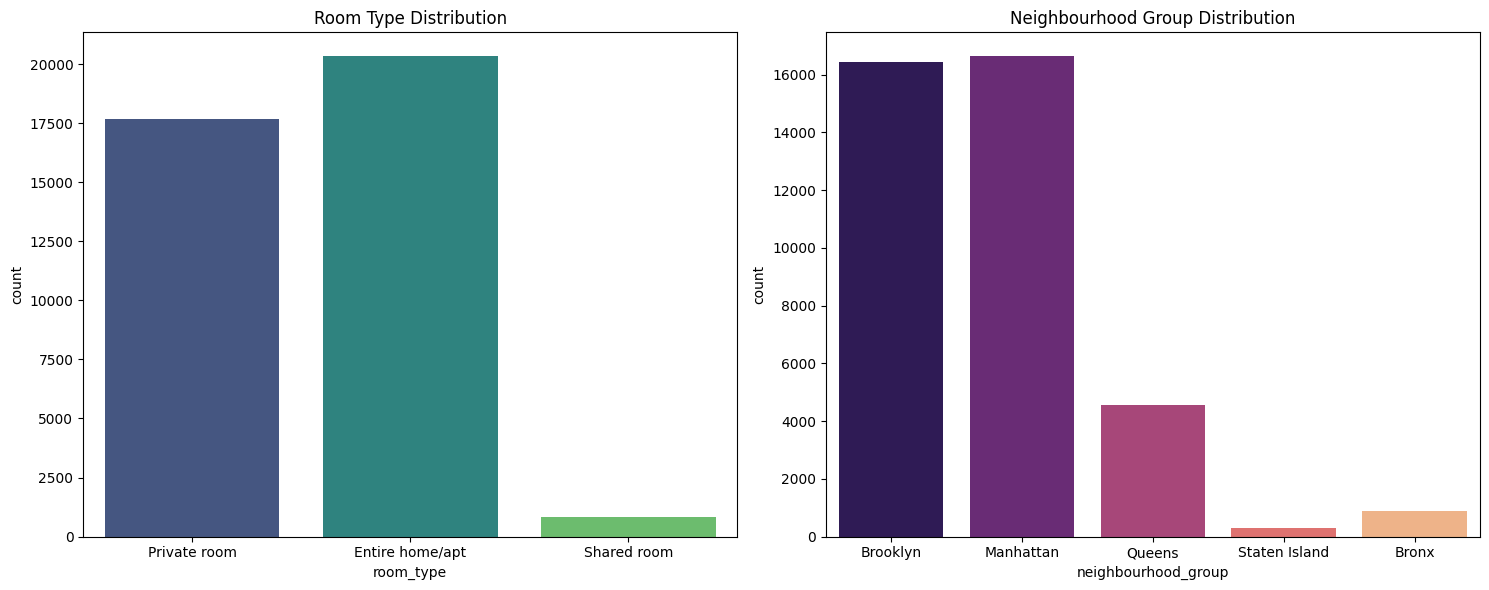

In [484]:
#-------------------------#
# b) Feature Distribution #
#-------------------------#

#Neighbourhood group and Room type distribution

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=df_eda, x='room_type', ax=axes[0], palette='viridis')
axes[0].set_title("Room Type Distribution")

sns.countplot(data=df_eda, x='neighbourhood_group', ax=axes[1], palette='magma')
axes[1].set_title("Neighbourhood Group Distribution")

plt.tight_layout()
plt.show()

C:\Users\Mestr\AppData\Local\Temp\ipykernel_13940\2730828899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


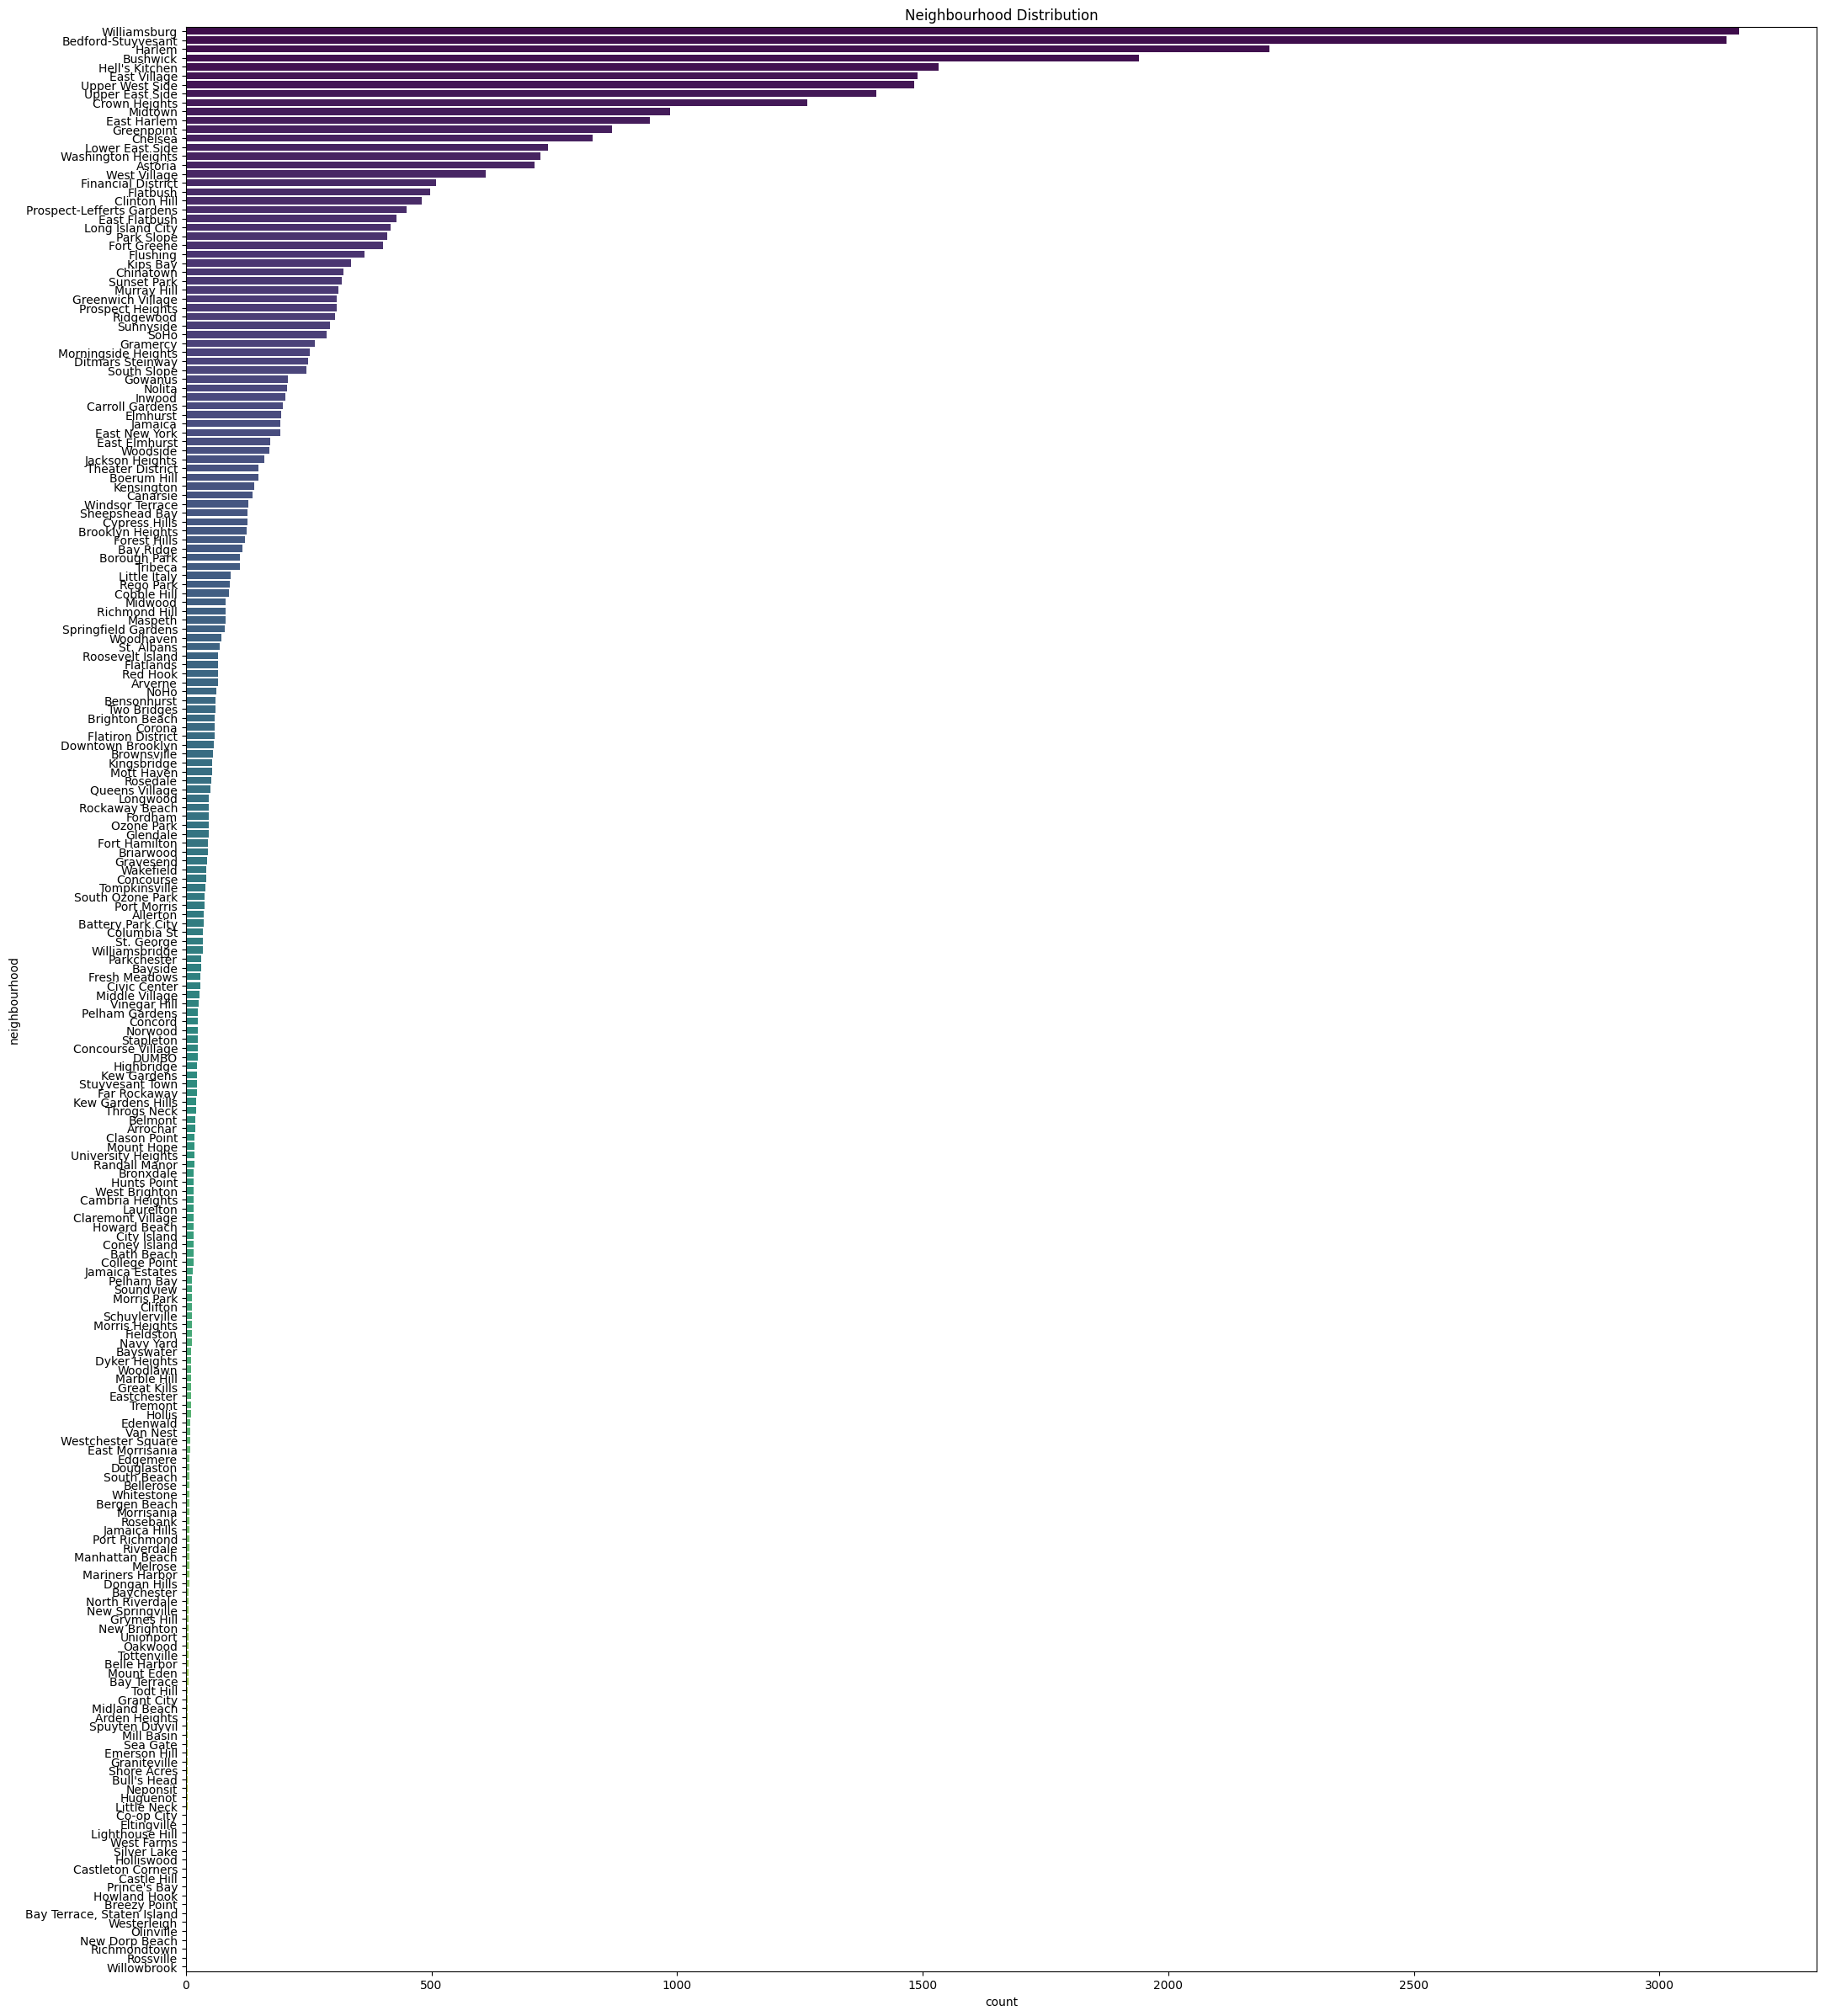

In [485]:
#Neighbourhood Distribution

plt.figure(figsize=(25, 30))
sns.countplot(
    data=df_eda,
    y='neighbourhood',
    order=df_eda['neighbourhood'].value_counts().index,
    palette='viridis'
)

plt.title("Neighbourhood Distribution")

plt.show()

C:\Users\Mestr\AppData\Local\Temp\ipykernel_13940\1709991556.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='room_type',y='log_price', ax=axes[0], palette='viridis')
C:\Users\Mestr\AppData\Local\Temp\ipykernel_13940\1709991556.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='neighbourhood_group',y='log_price', ax=axes[1], palette='magma')
C:\Users\Mestr\AppData\Local\Temp\ipykernel_13940\1709991556.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda[df_eda['neighbourhood'].isin(top_10_neig

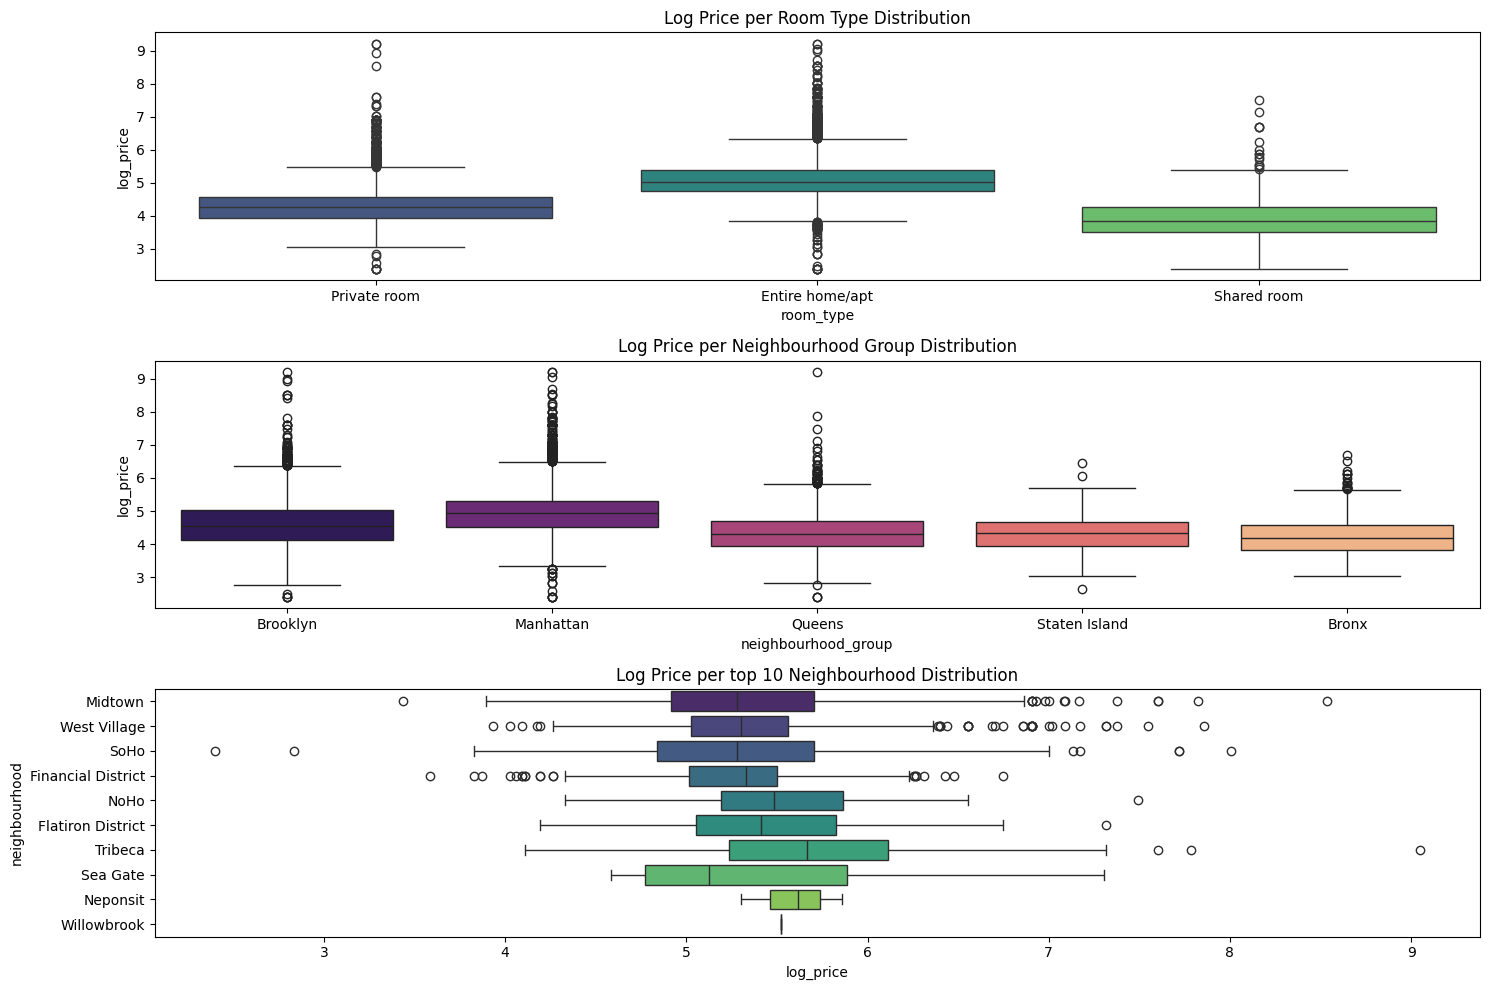

In [486]:
#-----------------------------------#
# c) Bivariate Analysis with target #
#-----------------------------------#

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

sns.boxplot(data=df_eda, x='room_type',y='log_price', ax=axes[0], palette='viridis')
axes[0].set_title("Log Price per Room Type Distribution")

sns.boxplot(data=df_eda, x='neighbourhood_group',y='log_price', ax=axes[1], palette='magma')
axes[1].set_title("Log Price per Neighbourhood Group Distribution")

top_10_neighbourhoods=df_eda.groupby('neighbourhood')['log_price'].mean().sort_values(ascending=False).head(10).index
sns.boxplot(data=df_eda[df_eda['neighbourhood'].isin(top_10_neighbourhoods)],y='neighbourhood', x='log_price', ax=axes[2], palette='viridis')
axes[2].set_title("Log Price per top 10 Neighbourhood Distribution")

plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 0 Axes>

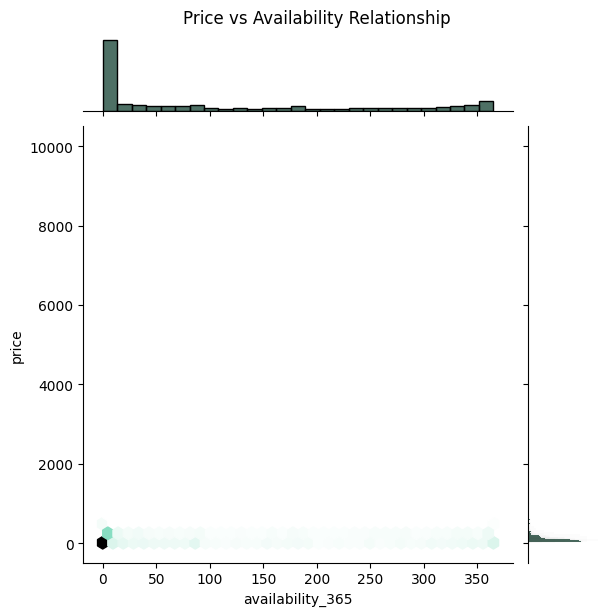

In [487]:
plt.figure(figsize=(14, 10))
sns.jointplot(data=df_eda, x='availability_365', y='price', kind='hex', color="#124031")
plt.suptitle("Price vs Availability Relationship", y=1.02)
plt.show()

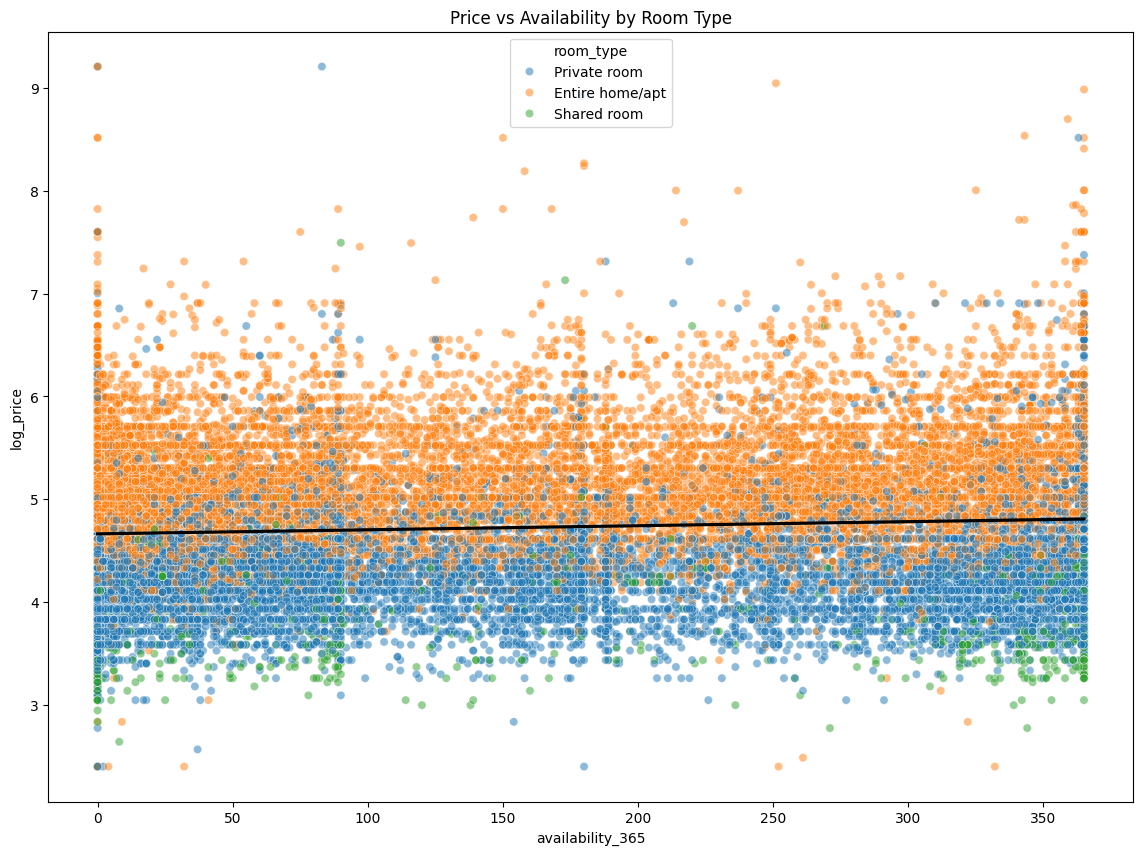

In [488]:
plt.figure(figsize=(14, 10))
sns.scatterplot(data=df_eda, x='availability_365',y='log_price', hue='room_type',alpha=0.5)
sns.regplot(data=df_eda, x='availability_365', y='log_price', scatter=False, color='black')

plt.title("Price vs Availability by Room Type")
plt.show()

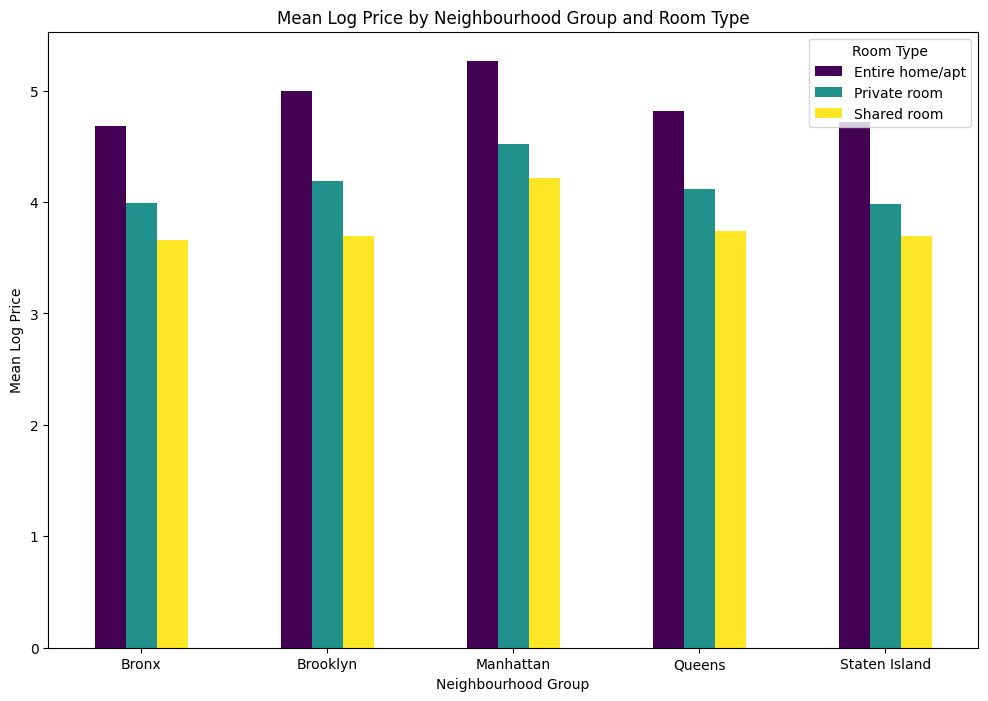

📊 Plotted mean Log Price by neighbourhood group and room type.


In [489]:
# mean log price by neighbourhood group and room type chart
mean_price = df_eda.groupby(['neighbourhood_group', 'room_type'])['log_price'].mean().unstack()
mean_price.plot(kind='bar', figsize=(12, 8), colormap='viridis')
plt.title('Mean Log Price by Neighbourhood Group and Room Type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Mean Log Price')
plt.xticks(rotation=0)
plt.legend(title='Room Type')
plt.show()
print("📊 Plotted mean Log Price by neighbourhood group and room type.")

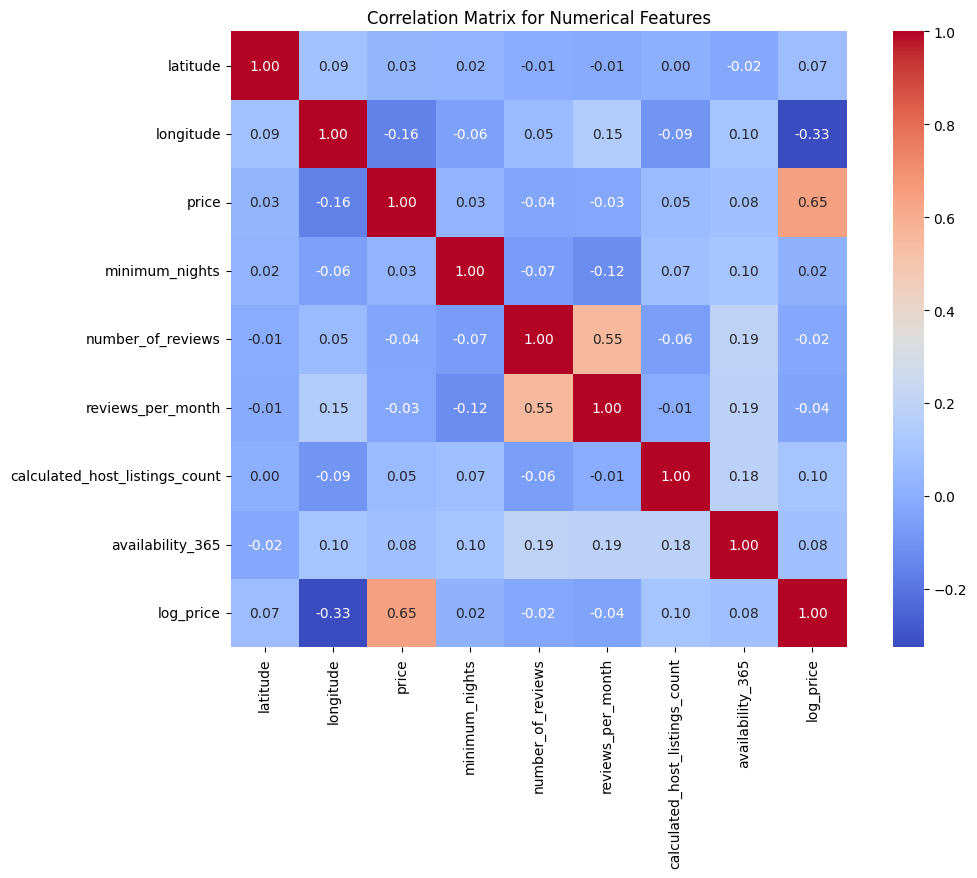

📈 Displayed feature correlation heatmap.


In [490]:
# 🔗 Checking how features are correlated with each other for numerical variables only (drop categorical variables, drop id, and drop host_id)
corr_matrix = df_eda.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix for Numerical Features')
plt.show()
print("📈 Displayed feature correlation heatmap.")

In [491]:
#------------------------#
# d) Outlier Exploration #
#------------------------#

df_outliers=df_eda.drop(columns=["price"], errors="ignore").copy()
df_outliers.head()



,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,1,9,0.21,6,365,5.010635
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,45,0.38,2,355,5.420535
2,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,270,4.64,1,194,4.499810
3,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,10,9,0.10,1,0,4.394449
4,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,3,74,0.59,1,129,5.303305


In [492]:
#Outliers in numerical cols
numerical_cols= df_outliers.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols

['latitude',
 'longitude',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'log_price']

In [493]:
import math
outlier_report=[]

for col in numerical_cols:
    Q1= df_outliers[col].quantile(0.25)
    Q3=df_outliers[col].quantile(0.75)
    IQR=Q3 - Q1

    lower_bound= Q1 - 1.5 * IQR
    upper_bound= Q3 + 1.5 * IQR

    outlier_count= ((df_outliers[col] < lower_bound) | (df_outliers[col] > upper_bound)).sum()
    outlier_pct= outlier_count / len(df_outliers)*100

    outlier_report.append({
        "variable":col,
        "min": df_outliers[col].min(),
        "Q1": Q1,
        "median": df_outliers[col].median(),
        "Q3": Q3,
        "max":df_outliers[col].max(),
        "IQR": IQR,
        "lower_bound":lower_bound,
        "upper_bound":upper_bound,
        "outlier_count":outlier_count,
        "outlier_pct":outlier_pct
    })


outlier_report_df=pd.DataFrame(outlier_report)
outlier_report_df.sort_values("outlier_pct", ascending=False)

,variable,min,Q1,median,Q3,max,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
5,calculated_host_listings_count,1.000000,1.000000,1.000000,2.000000,327.00000,1.000000,-0.500000,3.500000,5228,13.462777
2,minimum_nights,1.000000,1.000000,2.000000,4.000000,1250.00000,3.000000,-3.500000,8.500000,4462,11.490227
3,number_of_reviews,1.000000,3.000000,9.000000,33.000000,629.00000,30.000000,-42.000000,78.000000,4234,10.903098
1,longitude,-74.244420,-73.982470,-73.954810,-73.935020,-73.71299,0.047450,-74.053645,-73.863845,2299,5.920222
4,reviews_per_month,0.010000,0.190000,0.720000,2.020000,58.50000,1.830000,-2.555000,4.765000,1793,4.617207
7,log_price,2.397895,4.248495,4.624973,5.141664,9.21044,0.893168,2.908743,6.481416,415,1.068679
0,latitude,40.506410,40.688640,40.721720,40.763000,40.91306,0.074360,40.577100,40.874540,276,0.710736
6,availability_365,0.000000,0.000000,55.000000,229.000000,365.00000,229.000000,-343.500000,572.500000,0,0.000000


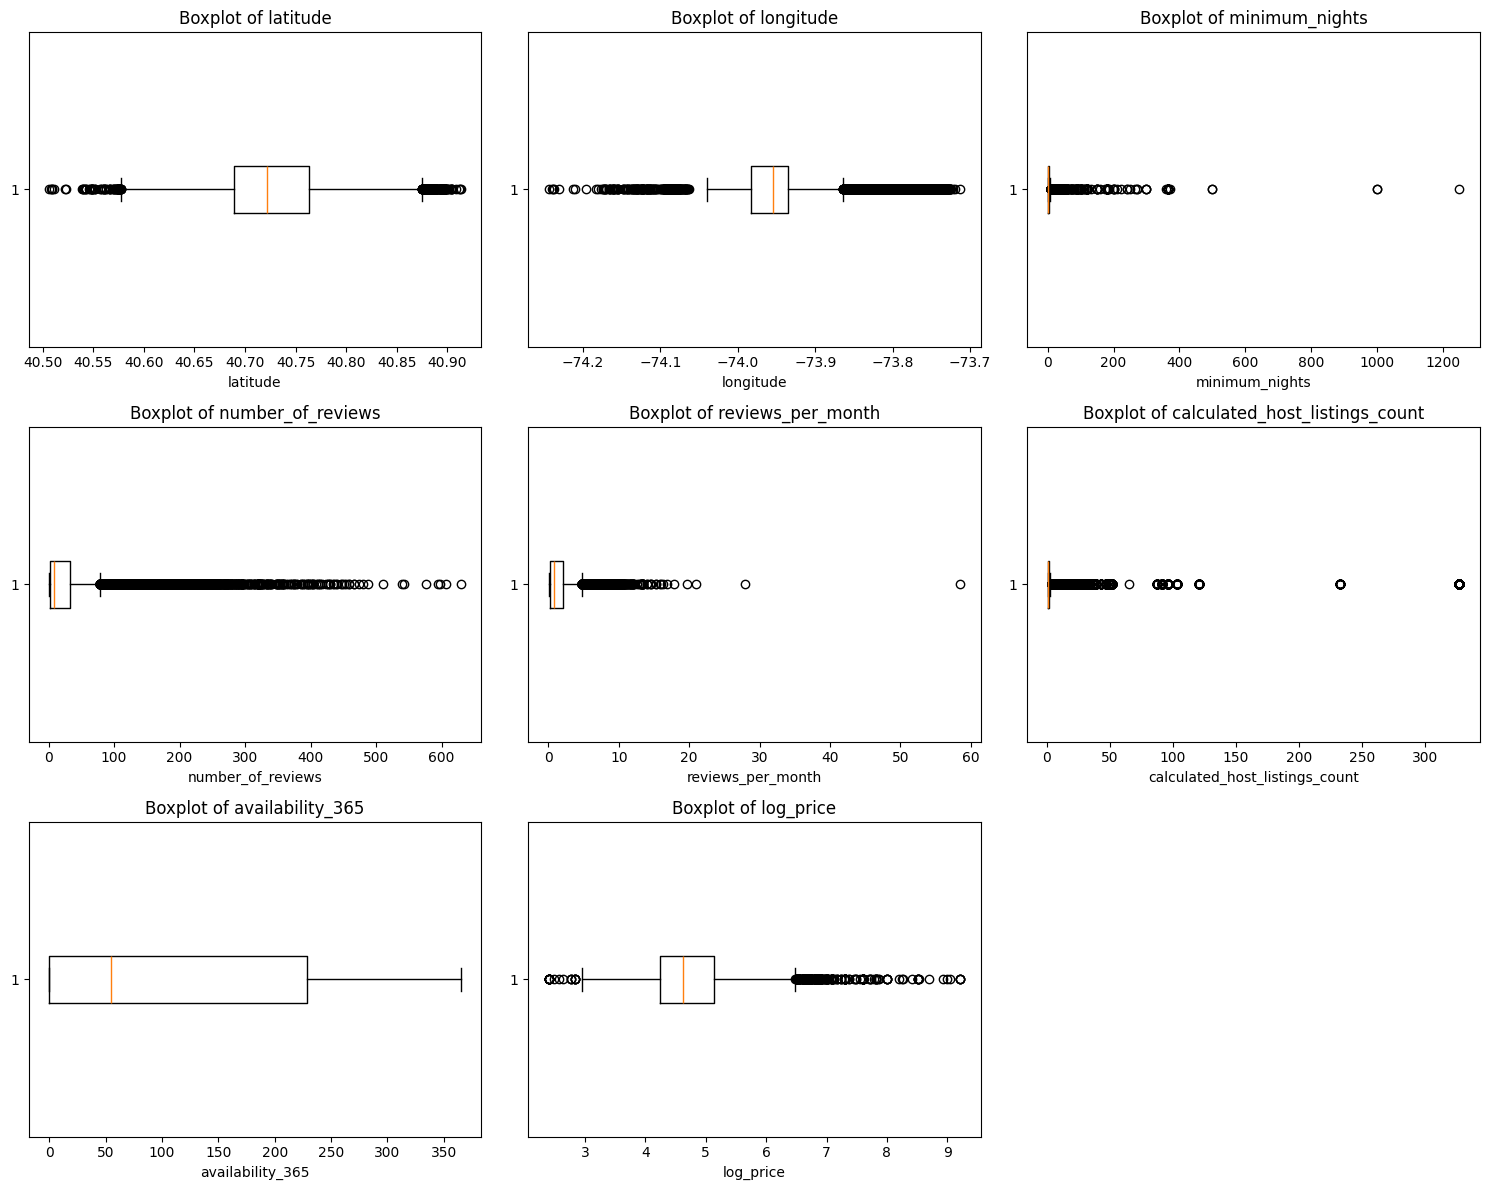

In [494]:
n_cols= 3
n_rows = math.ceil(len(numerical_cols)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4* n_rows))
axes=axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df_outliers[col].dropna(), vert=False)
    axes[i].set_title(f"Boxplot of {col}" )
    axes[i].set_xlabel(col)

#remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [495]:
# From the outlier analysis we observe that the calculated listings count has the highest percentage of outliers at approx. 13.5%, followed by minimum nights at 11.5% and 
# number of reviews at 10.9%, showing that these variables are naturally right-skewed in Airbnb context, since a small number of hosts may manage many listings with some
# listings possibly imposing unusually long minimum stays, and some propertires may accumulate significantly more reviews than others.

# Regarding Geographical variables, they show lower outlier rate, which should be inspected spatially, rather than facing auto-deletion, as they may present valid NYC locations.

# The dataset contains meaningful extreme values that should be treated carefully rather than blindly removed.

In [496]:
#-------------------------------------#
# e) Categorical Cardinality Analysis #
#-------------------------------------#
categorical_cols= df_outliers.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
categorical_cols

cardinality_report=[]

for col in categorical_cols:
    n_unique = df_eda[col].nunique(dropna=True)
    n_missing = df_eda[col].isna().sum()
    missing_pct = (n_missing / len(df_eda)) * 100

    most_frequent = df_eda[col].mode(dropna=True)
    most_frequent_value = most_frequent.iloc[0] if len(most_frequent) > 0 else None

    most_frequent_count = df_eda[col].value_counts(dropna=True).iloc[0] if n_unique > 0 else 0
    most_frequent_pct = (most_frequent_count / len(df_eda)) * 100

    cardinality_report.append({
        "variable":col,
        "n_unique": n_unique,
        "missing_pct": missing_pct,
        "most_frequent_value": most_frequent_value,
        "most_frequent_pct": most_frequent_pct
    })

cardinality_df = pd.DataFrame(cardinality_report)
cardinality_df.sort_values("n_unique", ascending=False)

,variable,n_unique,missing_pct,most_frequent_value,most_frequent_pct
1,neighbourhood,218,0.0,Williamsburg,8.142559
0,neighbourhood_group,5,0.0,Manhattan,42.829552
2,room_type,3,0.0,Entire home/apt,52.354956


In [497]:
def classify_cardinality(n_unique):
    if n_unique <=2:
        return "binary"
    elif n_unique <=10:
        return "low_cardinality"
    elif n_unique <=50:
        "medium_cardinality"
    else:
        return "high cardinality"

cardinality_df["cardinality_level"] = cardinality_df["n_unique"].apply(classify_cardinality)
cardinality_df.sort_values("n_unique", ascending=False)

,variable,n_unique,missing_pct,most_frequent_value,most_frequent_pct,cardinality_level
1,neighbourhood,218,0.0,Williamsburg,8.142559,high cardinality
0,neighbourhood_group,5,0.0,Manhattan,42.829552,low_cardinality
2,room_type,3,0.0,Entire home/apt,52.354956,low_cardinality


In [498]:
#Top Categories fro each categorical variable

for col in categorical_cols:
    print(f"\n{col}")
    print("-"*50)
    print(df_eda[col].value_counts(dropna=False).head(10))


neighbourhood_group
--------------------------------------------------
neighbourhood_group
Manhattan        16632
Brooklyn         16438
Queens            4574
Bronx              875
Staten Island      314
Name: count, dtype: int64

neighbourhood
--------------------------------------------------
neighbourhood
Williamsburg          3162
Bedford-Stuyvesant    3137
Harlem                2206
Bushwick              1941
Hell's Kitchen        1532
East Village          1490
Upper West Side       1482
Upper East Side       1405
Crown Heights         1265
Midtown                986
Name: count, dtype: int64

room_type
--------------------------------------------------
room_type
Entire home/apt    20331
Private room       17658
Shared room          844
Name: count, dtype: int64


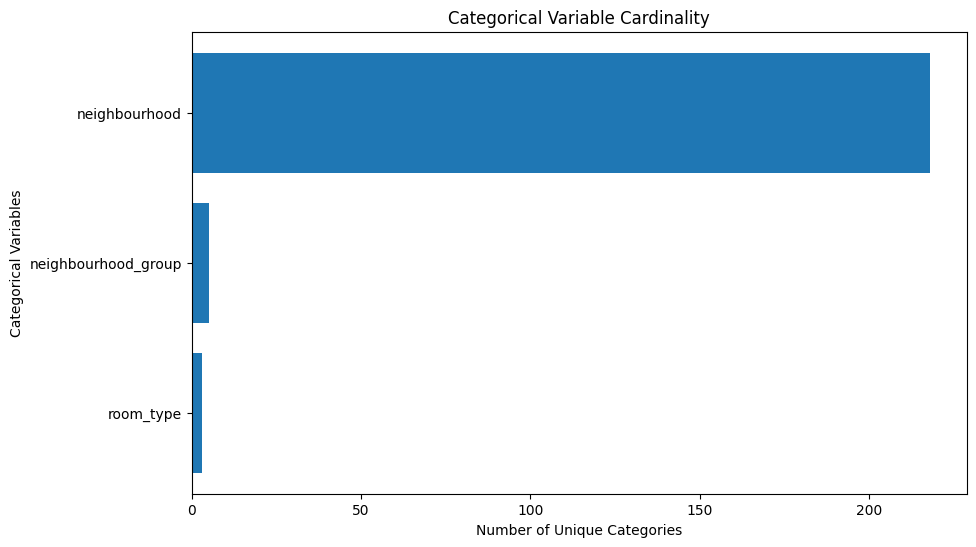

In [499]:
cardinality_plot_df=cardinality_df.sort_values("n_unique", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(cardinality_plot_df["variable"], cardinality_plot_df["n_unique"])
plt.title("Categorical Variable Cardinality")
plt.xlabel("Number of Unique Categories")
plt.ylabel("Categorical Variables")
plt.show()

In [500]:
rare_category_report= []
rare_threshold= 0.01 # categories representing less than 1% of rows

for col in categorical_cols:
    value_pct= df_eda[col].value_counts(normalize=True, dropna=True)
    rare_categories = value_pct[value_pct < rare_threshold] 

    rare_category_report.append({
        "variable":col,
        "n_unique": df_eda[col].nunique(dropna=True),
        "n_rare_categories": len(rare_categories),
        "rare_category_pct_of_categories": len(rare_categories) / df_eda[col].nunique(dropna=True)*100,
        "rows_in_rare_categories_pct": df_eda[col].isin(rare_categories.index).mean() * 100
    })

rare_category_df = pd.DataFrame(rare_category_report)
rare_category_df.sort_values("n_unique", ascending=False)

,variable,n_unique,n_rare_categories,rare_category_pct_of_categories,rows_in_rare_categories_pct
1,neighbourhood,218,193,88.53211,28.892952
0,neighbourhood_group,5,1,20.00000,0.808591
2,room_type,3,0,0.00000,0.000000


2- Data Quality Assessment

In [501]:
#--------------------------------------
# a)Missing data assessesment 
#--------------------------------------

# ❓ Checking for missing values to identify data quality issues
print("\n🔍 Missing values per column:")
print(df_eda.isnull().sum())


🔍 Missing values per column:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
log_price                         0
dtype: int64


In [502]:
#----------------------------------------------------------------
# b) Further Outlier Assessesment using the Mahalanobis Distance
#---------------------------------------------------------------

## 1. Select numeric predictors only

# Exclude target-related variables
target_cols = ["price", "log_price"]

# Select numeric predictor variables only
numeric_predictors = (
    df
    .drop(columns=target_cols, errors="ignore")
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

numeric_predictors

['latitude',
 'longitude',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [503]:
## 2. Inspect variance between variables

variance_report = (
    df_eda[numeric_predictors]
    .var()
    .reset_index()
    .rename(columns={"index": "variable", 0: "variance"})
    .sort_values("variance", ascending=False)
)

variance_report

,variable,variance
6,availability_365,16782.967015
3,number_of_reviews,2322.095605
5,calculated_host_listings_count,691.639212
2,minimum_nights,302.275440
4,reviews_per_month,2.823713
0,latitude,0.003024
1,longitude,0.002181


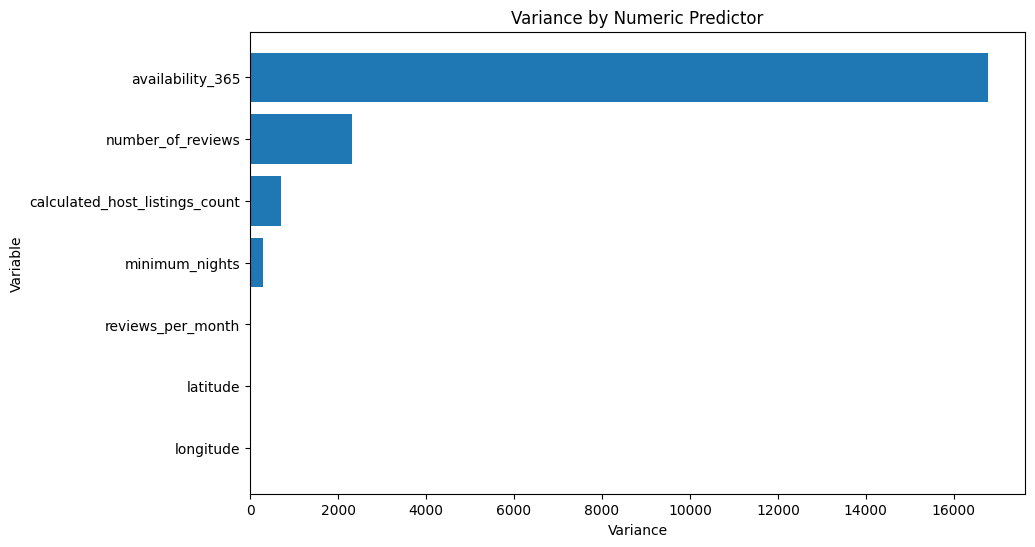

In [504]:
plt.figure(figsize=(10, 6))
plt.barh(
    variance_report["variable"],
    variance_report["variance"]
)
plt.title("Variance by Numeric Predictor")
plt.xlabel("Variance")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()

# Variables like number_of_reviews, minimum_nights, and calculated_host_listings_count can have very different scales, we should standardize before applying Mahalanobis distance

In [505]:
## 3. Prepare numeric matrix

# we will be using the median imputation just for diagnostic inspections
X_num = df_eda[numeric_predictors].copy()

# Median imputation for missing values
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_num)

# Standardize variables before Mahalanobis distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_predictors, index=df_eda.index)

X_scaled_df.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,-1.466574,-0.454298,-0.279973,-0.421175,-0.692186,0.031766,1.930735
1,0.463367,-0.698429,-0.279973,0.325906,-0.591018,-0.120333,1.853543
2,-0.781920,-0.184255,-0.279973,4.995166,1.944140,-0.158358,0.610755
3,1.279677,0.153459,0.237690,-0.421175,-0.757648,-0.158358,-0.886766
4,0.355168,-0.510619,-0.164937,0.927722,-0.466045,-0.158358,0.109009


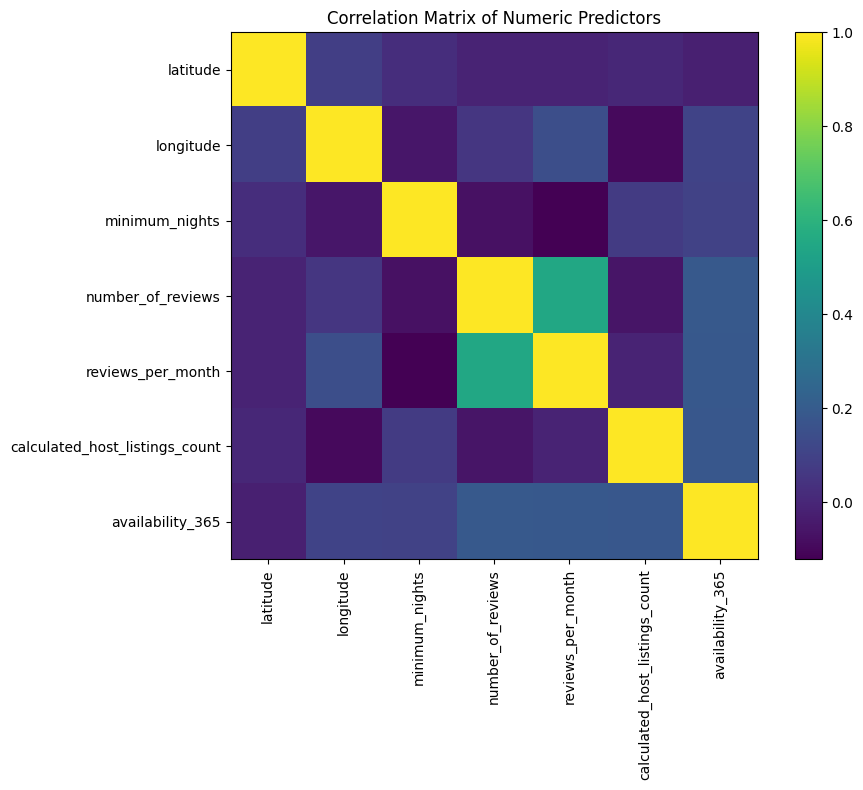

In [506]:
## 4. Inspect covariance / correlation structure

# since the Mahalanobis distance uses the covariance between variables, so need to inspect it first.

corr_matrix = X_scaled_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Numeric Predictors")
plt.tight_layout()
plt.show() 


In [507]:
##5. Mahalanobis Distance Calculation

# LedoitWolf covariance - it is more stable than directly inverting the sample covariance matrix, especially when variables are correlated

# Fit robust/stable covariance estimator
cov_estimator = LedoitWolf()
cov_estimator.fit(X_scaled)

mean_vector = cov_estimator.location_
precision_matrix = cov_estimator.precision_

# Mahalanobis squared distance
diff = X_scaled - mean_vector

mahalanobis_sq = np.sum(diff @ precision_matrix * diff, axis=1)

# Mahalanobis distance
mahalanobis_dist = np.sqrt(mahalanobis_sq)

# Store results
df_mahalanobis = df_eda.copy()
df_mahalanobis["mahalanobis_distance"] = mahalanobis_dist
df_mahalanobis["mahalanobis_sq"] = mahalanobis_sq

df_mahalanobis[["mahalanobis_distance", "mahalanobis_sq"]].describe()

,mahalanobis_distance,mahalanobis_sq
count,38833.000000,38833.000000
mean,2.161810,6.951715
std,1.509420,40.984835
min,0.244948,0.060000
25%,1.386982,1.923718
50%,1.791798,3.210540
75%,2.500048,6.250240
max,72.438570,5247.346429


In [508]:
## 6. Flag multivariate outliers

# Mahalanobis squared distance approximately follows a chi-square distribution with degrees of freedom equal to the number of variables

n_features = len(numeric_predictors)

# 99th percentile threshold
threshold_99 = chi2.ppf(0.99, df=n_features)

# 97.5th percentile threshold, optional less strict threshold
threshold_975 = chi2.ppf(0.975, df=n_features)

df_mahalanobis["mahalanobis_outlier_99"] = df_mahalanobis["mahalanobis_sq"] > threshold_99
df_mahalanobis["mahalanobis_outlier_975"] = df_mahalanobis["mahalanobis_sq"] > threshold_975

print("Number of numeric predictors:", n_features)
print("99% threshold:", threshold_99)
print("97.5% threshold:", threshold_975)

print("Outliers at 99% threshold:")
print(df_mahalanobis["mahalanobis_outlier_99"].value_counts(normalize=True) * 100)

print("Outliers at 97.5% threshold:")
print(df_mahalanobis["mahalanobis_outlier_975"].value_counts(normalize=True) * 100)

Number of numeric predictors: 7
99% threshold: 18.475306906582357
97.5% threshold: 16.012764274629326
Outliers at 99% threshold:
mahalanobis_outlier_99
False    95.151031
True      4.848969
Name: proportion, dtype: float64
Outliers at 97.5% threshold:
mahalanobis_outlier_975
False    93.763037
True      6.236963
Name: proportion, dtype: float64


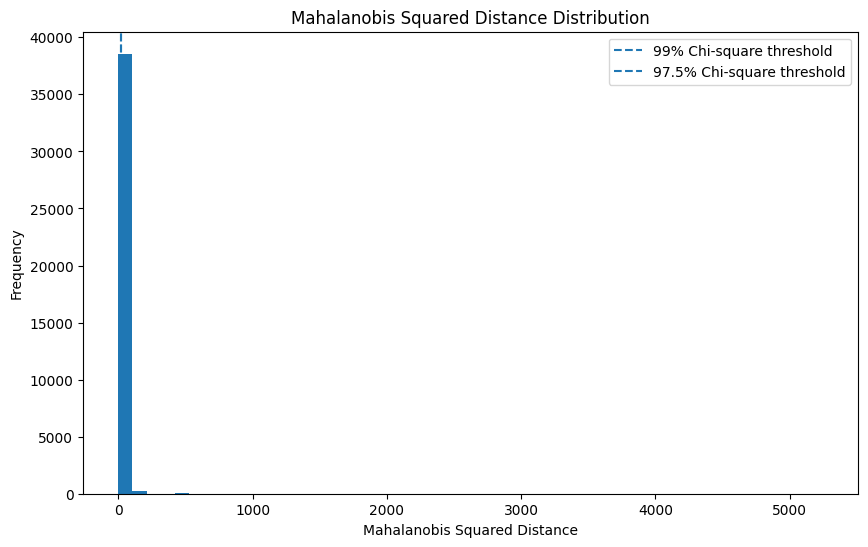

In [509]:
## 7. Plot Mahalanobis distance distribution

plt.figure(figsize=(10, 6))
plt.hist(df_mahalanobis["mahalanobis_sq"], bins=50)
plt.axvline(threshold_99, linestyle="--", label="99% Chi-square threshold")
plt.axvline(threshold_975, linestyle="--", label="97.5% Chi-square threshold")
plt.title("Mahalanobis Squared Distance Distribution")
plt.xlabel("Mahalanobis Squared Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [510]:
## 8. Inspect the most extreme rows

top_mahalanobis_outliers = (
    df_mahalanobis
    .sort_values("mahalanobis_distance", ascending=False)
    [
        numeric_predictors 
        + ["mahalanobis_distance", "mahalanobis_sq", "mahalanobis_outlier_99"]
    ]
    .head(10)
)

top_mahalanobis_outliers

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,mahalanobis_distance,mahalanobis_sq,mahalanobis_outlier_99
5247,40.73293,-73.99782,1250,2,0.03,1,365,72.438570,5247.346429,True
11308,40.82915,-73.94034,999,2,0.07,1,42,58.057448,3370.667231,True
21991,40.71772,-73.95059,999,24,1.12,6,249,57.963752,3359.796545,True
35003,40.75918,-73.98801,1,156,58.50,9,299,39.201118,1536.727684,True
6539,40.75104,-73.93863,500,30,0.57,1,90,28.888642,834.553663,True
9669,40.67255,-73.94914,500,10,0.22,1,365,28.723315,825.028827,True
1250,40.70202,-73.92402,370,6,0.09,1,365,21.148885,447.275353,True
33316,40.78724,-73.94940,365,1,0.57,1,0,21.073162,444.078172,True
13220,40.78147,-73.95284,365,27,0.78,1,17,21.070929,443.984046,True
26511,40.68458,-73.96805,365,1,0.09,2,0,21.066917,443.814983,True


In [511]:
## 9. Inspect which variables contribute to extreme observations

# Get top outlier indices
top_outlier_indices = (
    df_mahalanobis
    .sort_values("mahalanobis_distance", ascending=False)
    .head(10)
    .index
)

# Show standardized values for top outliers
top_outlier_zscores = X_scaled_df.loc[top_outlier_indices].copy()

top_outlier_zscores["mahalanobis_distance"] = df_mahalanobis.loc[
    top_outlier_indices, 
    "mahalanobis_distance"
]

top_outlier_zscores

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,mahalanobis_distance
5247,0.087126,-0.999309,71.560073,-0.566441,-0.799305,-0.158358,1.930735,72.438570
11308,1.836856,0.231623,57.123042,-0.566441,-0.775501,-0.158358,-0.562560,58.057448
21991,-0.189463,0.012120,57.123042,-0.109891,-0.150638,0.031766,1.035310,57.963752
35003,0.564474,-0.789228,-0.279973,2.629408,33.996622,0.145840,1.421269,39.201118
6539,0.416450,0.268243,28.421535,0.014622,-0.477947,-0.158358,-0.192039,28.888642
9669,-1.010865,0.043172,28.421535,-0.400423,-0.686235,-0.158358,1.930735,28.723315
1250,-0.474963,0.581115,20.944188,-0.483432,-0.763599,-0.158358,1.930735,21.148885
33316,1.074736,0.037604,20.656598,-0.587194,-0.477947,-0.158358,-0.886766,21.073162
13220,0.969810,-0.036064,20.656598,-0.047635,-0.352975,-0.158358,-0.755540,21.070929
26511,-0.792104,-0.361785,20.656598,-0.587194,-0.763599,-0.120333,-0.886766,21.066917


In [512]:
for idx in top_outlier_indices[:10]:
    print(f"\nRow index: {idx}")
    print(f"Mahalanobis distance: {df_mahalanobis.loc[idx, 'mahalanobis_distance']:.2f}")
    print("-" * 50)
    
    row_zscores = X_scaled_df.loc[idx].abs().sort_values(ascending=False)
    print(row_zscores.head(5))


Row index: 5247
Mahalanobis distance: 72.44
--------------------------------------------------
minimum_nights       71.560073
availability_365      1.930735
longitude             0.999309
reviews_per_month     0.799305
number_of_reviews     0.566441
Name: 5247, dtype: float64

Row index: 11308
Mahalanobis distance: 58.06
--------------------------------------------------
minimum_nights       57.123042
latitude              1.836856
reviews_per_month     0.775501
number_of_reviews     0.566441
availability_365      0.562560
Name: 11308, dtype: float64

Row index: 21991
Mahalanobis distance: 57.96
--------------------------------------------------
minimum_nights       57.123042
availability_365      1.035310
latitude              0.189463
reviews_per_month     0.150638
number_of_reviews     0.109891
Name: 21991, dtype: float64

Row index: 35003
Mahalanobis distance: 39.20
--------------------------------------------------
reviews_per_month    33.996622
number_of_reviews     2.629408
ava

In [513]:
#----------------------------------------------------------------
# c) Sparse Categorical Variables
#---------------------------------------------------------------

# The categorical sparsity assessment showed that "neighbourhood" is the main sparse categorical variable meaning it will need a non- enconding strategy before modelling.

In [514]:
#----------------------------------------------------------------
# d) Potential Leaking Variables Assessment
#---------------------------------------------------------------

leakage_review = pd.DataFrame({
    "variable": [
        "price",
        "log_price",
        "number_of_reviews",
        "last_review",
        "reviews_per_month",
        "availability_365",
        "calculated_host_listings_count",
        "minimum_nights",
        "room_type",
        "neighbourhood_group",
        "neighbourhood",
        "latitude",
        "longitude"
    ],
    "leakage_risk": [
        "target",
        "target_transformation",
        "medium",
        "medium",
        "medium",
        "medium",
        "low",
        "low",
        "low",
        "low",
        "low",
        "low",
        "low"
    ],
    "reason": [
        "Target variable, must be excluded from features",
        "Derived from target, must be excluded from features",
        "May reflect listing popularity after price was set",
        "May contain post-listing review information",
        "May reflect demand after price was set",
        "May reflect future booking availability depending on snapshot timing",
        "Host portfolio size is likely known at prediction time",
        "Listing rule known at prediction time",
        "Listing attribute known at prediction time",
        "Location attribute known at prediction time",
        "Location attribute known at prediction time",
        "Location attribute known at prediction time",
        "Location attribute known at prediction time"
    ],
    "initial_decision": [
        "exclude",
        "exclude",
        "review",
        "review_or_transform",
        "review",
        "review",
        "keep",
        "keep",
        "keep",
        "keep",
        "treat_for_cardinality",
        "keep",
        "keep"
    ]
})

leakage_review

,variable,leakage_risk,reason,initial_decision
0,price,target,"Target variable, must be excluded from features",exclude
1,log_price,target_transformation,"Derived from target, must be excluded from fea...",exclude
2,number_of_reviews,medium,May reflect listing popularity after price was...,review
3,last_review,medium,May contain post-listing review information,review_or_transform
4,reviews_per_month,medium,May reflect demand after price was set,review
5,availability_365,medium,May reflect future booking availability depend...,review
6,calculated_host_listings_count,low,Host portfolio size is likely known at predict...,keep
7,minimum_nights,low,Listing rule known at prediction time,keep
8,room_type,low,Listing attribute known at prediction time,keep
9,neighbourhood_group,low,Location attribute known at prediction time,keep


In [515]:
#----------------------------------------------------------------
# e) Bias and Representiveness Issues
#---------------------------------------------------------------

# Representation by neighbourhood group
neighbourhood_group_rep = (
    df["neighbourhood_group"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

neighbourhood_group_rep.columns = ["neighbourhood_group", "row_pct"]

neighbourhood_group_rep

,neighbourhood_group,row_pct
0,Manhattan,42.818526
1,Brooklyn,42.342250
2,Queens,11.775610
3,Bronx,2.255233
4,Staten Island,0.808382


In [516]:
# Representation by room type
room_type_rep = (
    df["room_type"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

room_type_rep.columns = ["room_type", "row_pct"]

room_type_rep

,room_type,row_pct
0,Entire home/apt,52.344052
1,Private room,45.477950
2,Shared room,2.177999


In [517]:
# Price distribution by neighbourhood group
df.groupby("neighbourhood_group")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,876.0,79.553653,63.962726,0.0,45.0,65.0,95.0,800.0
Brooklyn,16447.0,121.448714,169.851030,0.0,60.0,94.0,150.0,10000.0
Manhattan,16632.0,180.052489,226.405766,10.0,90.0,140.0,200.0,9999.0
Queens,4574.0,95.762571,168.361417,10.0,50.0,72.0,109.0,10000.0
Staten Island,314.0,89.964968,65.864044,13.0,50.0,75.0,105.0,625.0


In [518]:
# Price distribution by room type
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,20332.0,196.294068,223.646417,0.0,116.0,151.0,220.0,10000.0
Private room,17665.0,83.981093,142.238423,0.0,50.0,70.0,94.0,10000.0
Shared room,846.0,63.213948,95.186458,0.0,32.0,45.0,70.0,1800.0


In [519]:
# From the representativeness assessment, there has been identified segment imbalances in neighbourhood groups with some groups not being well representend and room types, with shared room
# not being well reperesented.

#The model may perform well overall but struggle predition these segments meaning a segment-level evaluation may be required during EVALUATION.

In [520]:
# Overall, the dataset is usable for modeling, but several data quality risks require controlled treatment. Missing values must be handled according to their pattern and modeling relevance. 
# `neighbourhood` is the only major sparse categorical variable and should not be directly one-hot encoded without treatment. Outliers appear concentrated in operational variables such as
#  host listing count, minimum nights, and review activity; these require further assessment rather than automatic removal. Potential leakage is mainly associated with target-derived variables 
# and review/availability features, which may contain post-listing information depending on the prediction scenario. Finally, representativeness should be monitored across neighbourhood groups, 
# room types, and price ranges to ensure that model performance is not driven only by dominant listing segments.

3- Modelling Feasibility Judgement

In [521]:
import pandas as pd

modelling_feasibility = pd.DataFrame({
    "area": [
        "Target suitability",
        "Categorical features",
        "Numeric outliers",
        "Multivariate outliers",
        "Leakage risk",
        "Representativeness",
        "Overall decision"
    ],
    "finding": [
        "Raw price is highly skewed; log_price is much more stable",
        "neighbourhood is high-cardinality and sparse; room_type and neighbourhood_group are usable",
        "Outliers concentrated in host listing count, minimum nights, and review variables",
        "Mahalanobis distance flags 4.85% to 6.24% of rows as unusual combinations",
        "Review-related and availability variables may contain post-listing information",
        "Manhattan/Brooklyn and main room types dominate the dataset",
        "Dataset is usable for modelling with safeguards"
    ],
    "risk_level": [
        "Low after log transform",
        "Medium",
        "Medium",
        "Medium",
        "Medium",
        "Medium",
        "Acceptable"
    ],
    "decision": [
        "Use log_price as target",
        "Treat neighbourhood carefully before encoding",
        "Inspect and treat outliers; do not blindly remove",
        "Use as diagnostic, not deletion rule",
        "Run controlled experiments with/without risky variables",
        "Evaluate metrics by segment",
        "Proceed to feature engineering, Pipelines and baselines, and experiments"
    ]
})

modelling_feasibility

,area,finding,risk_level,decision
0,Target suitability,Raw price is highly skewed; log_price is much ...,Low after log transform,Use log_price as target
1,Categorical features,neighbourhood is high-cardinality and sparse; ...,Medium,Treat neighbourhood carefully before encoding
2,Numeric outliers,"Outliers concentrated in host listing count, m...",Medium,Inspect and treat outliers; do not blindly remove
3,Multivariate outliers,Mahalanobis distance flags 4.85% to 6.24% of r...,Medium,"Use as diagnostic, not deletion rule"
4,Leakage risk,Review-related and availability variables may ...,Medium,Run controlled experiments with/without risky ...
5,Representativeness,Manhattan/Brooklyn and main room types dominat...,Medium,Evaluate metrics by segment
6,Overall decision,Dataset is usable for modelling with safeguards,Acceptable,"Proceed to feature engineering, Pipelines and ..."


Post Experiments EDA: 

Further Raw Price Analysis

In [522]:
price_percentiles = df_eda["price"].describe(
    percentiles=[
        0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999
    ]
)

price_percentiles

count    38833.000000
mean       142.354595
std        196.957737
min         10.000000
50%        101.000000
75%        170.000000
90%        250.000000
95%        330.000000
97.5%      450.000000
99%        671.360000
99.5%      889.680000
99.9%     2000.000000
max      10000.000000
Name: price, dtype: float64

In [523]:
Q1 = df_eda["price"].quantile(0.25)
Q3 = df_eda["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_iqr_outliers = df_eda[df_eda["price"] > upper_bound]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)
print("Outlier count:", len(price_iqr_outliers))
print("Outlier pct:", len(price_iqr_outliers) / len(df_eda) * 100)

Q1: 69.0
Q3: 170.0
IQR: 101.0
Upper bound: 321.5
Outlier count: 2077
Outlier pct: 5.348543764324157


In [524]:
price_median = df_eda["price"].median()
mad = np.median(np.abs(df_eda["price"] - price_median))

df_eda["price_modified_z"] = 0.6745 * (df_eda["price"] - price_median) / mad

extreme_modified_z = df_eda[df_eda["price_modified_z"].abs() > 3.5]

print("Median price:", price_median)
print("MAD:", mad)
print("Extreme count:", len(extreme_modified_z))
print("Extreme pct:", len(extreme_modified_z) / len(df_eda) * 100)

Median price: 101.0
MAD: 45.0
Extreme count: 1932
Extreme pct: 4.975150001287565


In [525]:
df_eda.sort_values("price_modified_z", ascending=False)[
    ["price", "room_type", "neighbourhood_group", "neighbourhood", 
     "minimum_nights", "number_of_reviews", "availability_365"]
].head(10)

,price,room_type,neighbourhood_group,neighbourhood,minimum_nights,number_of_reviews,availability_365
8014,10000.0,Private room,Queens,Astoria,100,2,0
14642,10000.0,Entire home/apt,Brooklyn,Greenpoint,5,5,0
5880,9999.0,Entire home/apt,Manhattan,East Harlem,5,1,0
10550,9999.0,Private room,Manhattan,Lower East Side,99,6,83
25243,8500.0,Entire home/apt,Manhattan,Tribeca,30,2,251
4003,8000.0,Entire home/apt,Brooklyn,Clinton Hill,1,1,365
37550,7500.0,Private room,Brooklyn,East Flatbush,1,8,179
3315,6000.0,Entire home/apt,Manhattan,Upper West Side,14,17,359
35719,5100.0,Entire home/apt,Manhattan,Midtown,30,1,343
21551,5000.0,Entire home/apt,Brooklyn,Cypress Hills,2,4,0


In [526]:
total_price_sum = df_eda["price"].sum()

tail_concentration = []

for q in [0.90, 0.95, 0.975, 0.99, 0.995]:
    threshold = df_eda["price"].quantile(q)
    tail_sum = df_eda.loc[df_eda["price"] > threshold, "price"].sum()
    tail_rows = (df_eda["price"] > threshold).sum()
    
    tail_concentration.append({
        "quantile": q,
        "threshold": threshold,
        "tail_rows": tail_rows,
        "tail_rows_pct": tail_rows / len(df_eda) * 100,
        "tail_price_share_pct": tail_sum / total_price_sum * 100
    })

tail_concentration_df = pd.DataFrame(tail_concentration)
tail_concentration_df

,quantile,threshold,tail_rows,tail_rows_pct,tail_price_share_pct
0,0.900,250.00,3531,9.092782,29.512038
1,0.950,330.00,1941,4.998326,21.164999
2,0.975,450.00,894,2.302166,13.882005
3,0.990,671.36,389,1.001725,8.983990
4,0.995,889.68,195,0.502150,6.339968


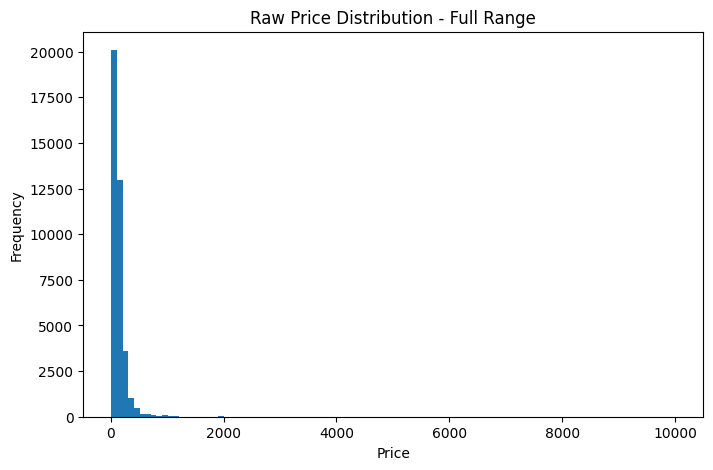

In [527]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["price"], bins=100)
plt.title("Raw Price Distribution - Full Range")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

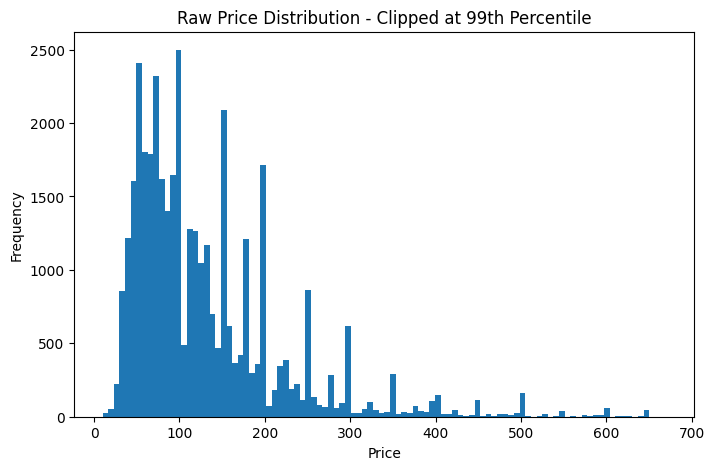

In [528]:
p99 = df_eda["price"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(df_eda[df_eda["price"] <= p99]["price"], bins=100)
plt.title("Raw Price Distribution - Clipped at 99th Percentile")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

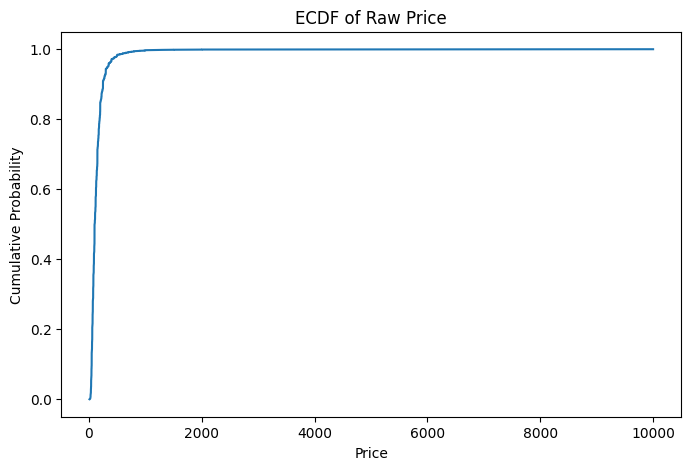

In [529]:
price_sorted = np.sort(df_eda["price"])
ecdf = np.arange(1, len(price_sorted) + 1) / len(price_sorted)

plt.figure(figsize=(8, 5))
plt.plot(price_sorted, ecdf)
plt.title("ECDF of Raw Price")
plt.xlabel("Price")
plt.ylabel("Cumulative Probability")
plt.show()

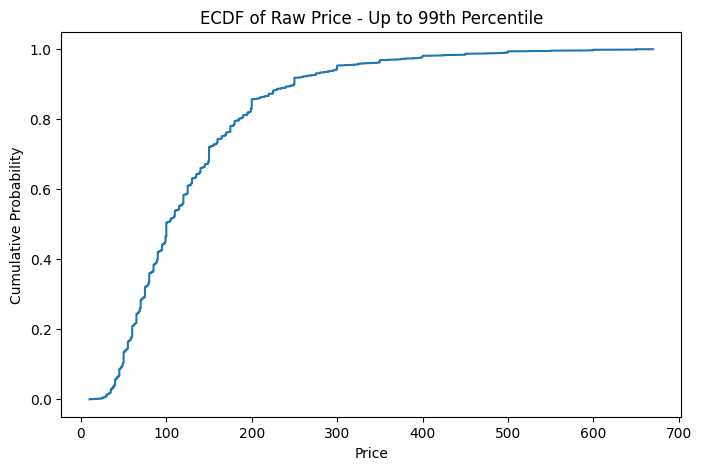

In [530]:
price_sorted_clipped = np.sort(df_eda[df_eda["price"] <= p99]["price"])
ecdf_clipped = np.arange(1, len(price_sorted_clipped) + 1) / len(price_sorted_clipped)

plt.figure(figsize=(8, 5))
plt.plot(price_sorted_clipped, ecdf_clipped)
plt.title("ECDF of Raw Price - Up to 99th Percentile")
plt.xlabel("Price")
plt.ylabel("Cumulative Probability")
plt.show()

In [531]:
df_eda.groupby(["neighbourhood_group", "room_type"])["price"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count        mean         std   min  \
neighbourhood_group room_type                                               
Bronx               Entire home/apt   309.0  120.789644   76.393788  35.0   
                    Private room      523.0   57.202677   26.902282  21.0   
                    Shared room        43.0   56.930233  118.473504  20.0   
Brooklyn            Entire home/apt  8163.0  171.270244  200.971670  10.0   
                    Private room     7987.0   73.394892  114.064112  10.0   
                    Shared room       288.0   45.774306   37.635161  15.0   
Manhattan           Entire home/apt  9967.0  230.190830  254.095016  10.0   
                    Private room     6309.0  106.603265  151.363275  10.0   
                    Shared room       356.0   77.980337   69.776118  10.0   
Queens              Entire home/apt  1742.0  139.225603   96.904710  10.0   
                    Private room     2680.0   69.286567  196.282939  10.0   
                    Shared room       152.0   64.467105  177.237294  15.0   
Staten Island       Entire home/apt   150.0  125.366667   76.175038  48.0   
                    Private room      159.0   57.584906   27.591345  20.0   
                    Shared room         5.0   57.600000   57.020172  13.0   

                                       50%     75%    90%     95%     99%  \
neighbourhood_group room_type                                               
Bronx               Entire home/apt  100.0  139.00  195.0  268.00  450.00   
                    Private room      50.0   68.00   80.0   99.00  142.00   
                    Shared room       28.0   50.00   60.0   69.50  533.30   
Brooklyn            Entire home/apt  143.0  195.00  271.6  350.00  607.22   
                    Private room      64.0   80.00  100.0  125.00  210.28   
                    Shared room       36.0   45.25   75.0  100.00  203.25   
Manhattan           Entire home/apt  182.0  250.00  369.0  499.00  999.00   
                    Private room      89.0  115.00  155.0  200.00  425.00   
                    Shared room       65.5   85.00  112.5  150.00  333.50   
Queens              Entire home/apt  120.0  159.75  227.7  284.90  400.00   
                    Private room      59.0   75.00   95.0  110.00  200.00   
                    Shared room       36.5   48.25   70.0  106.35  867.50   
Staten Island       Entire home/apt  100.0  149.75  200.0  275.00  365.79   
                    Private room      50.0   69.50   91.0  105.50  131.52   
                    Shared room       30.0   75.00  120.0  135.00  147.00   

                                         max  
neighbourhood_group room_type                 
Bronx               Entire home/apt    670.0  
                    Private room       300.0  
                    Shared room        800.0  
Brooklyn            Entire home/apt  10000.0  
                    Private room      7500.0  
                    Shared room        400.0  
Manhattan           Entire home/apt   9999.0  
                    Private room      9999.0  
                    Shared room        800.0  
Queens              Entire home/apt   2600.0  
                    Private room     10000.0  
                    Shared room       1800.0  
Staten Island       Entire home/apt    625.0  
                    Private room       235.0  
                    Shared room        150.0

In [532]:
top_price_cols = [
    "price",
    "room_type",
    "neighbourhood_group",
    "neighbourhood",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count"
]

df_eda.sort_values("price", ascending=False)[top_price_cols].head(5)

,price,room_type,neighbourhood_group,neighbourhood,minimum_nights,number_of_reviews,reviews_per_month,availability_365,calculated_host_listings_count
8014,10000.0,Private room,Queens,Astoria,100,2,0.04,0,1
14642,10000.0,Entire home/apt,Brooklyn,Greenpoint,5,5,0.16,0,1
5880,9999.0,Entire home/apt,Manhattan,East Harlem,5,1,0.02,0,1
10550,9999.0,Private room,Manhattan,Lower East Side,99,6,0.14,83,1
25243,8500.0,Entire home/apt,Manhattan,Tribeca,30,2,0.18,251,1


In [533]:
df_eda["log_price"] = np.log1p(df["price"])

comparison = pd.DataFrame({
    "price_quantiles": df_eda["price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]),
    "log_price_quantiles": df_eda["log_price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999])
})

comparison

,price_quantiles,log_price_quantiles
0.500,101.00,4.624973
0.750,170.00,5.141664
0.900,250.00,5.525453
0.950,330.00,5.802118
0.990,671.36,6.510793
0.995,889.68,6.791985
0.999,2000.00,7.601402


In [534]:
spearman_corr_check = df_eda[["price", "log_price", "calculated_host_listings_count"]].corr(method="spearman")
spearman_corr_check

,price,log_price,calculated_host_listings_count
price,1.000000,1.000000,-0.163522
log_price,1.000000,1.000000,-0.163522
calculated_host_listings_count,-0.163522,-0.163522,1.000000


In [535]:
df_price_qc = df_eda.copy()

segment_cols = ["neighbourhood_group", "room_type"]

# Segment-level thresholds
df_price_qc["segment_p99"] = df_price_qc.groupby(segment_cols)["price"].transform(
    lambda x: x.quantile(0.99)
)

df_price_qc["segment_p95"] = df_price_qc.groupby(segment_cols)["price"].transform(
    lambda x: x.quantile(0.95)
)

df_price_qc["segment_p935"] = df_price_qc.groupby(segment_cols)["price"].transform(
    lambda x: x.quantile(0.935)
)

df_price_qc["segment_p905"] = df_price_qc.groupby(segment_cols)["price"].transform(
    lambda x: x.quantile(0.905)
)

# Global extreme threshold
global_p935 = df_price_qc["price"].quantile(0.90)

df_price_qc["price_quality_flag"] = "normal"

# Suspicious entires rooms
entire_home_error = (
    (df_price_qc["room_type"] == "Entire home/apt") &
    (df_price_qc["price"] > df_price_qc["segment_p905"])
)

# Suspicious shared rooms
shared_room_error = (
    (df_price_qc["room_type"] == "Shared room") &
    (df_price_qc["price"] > df_price_qc["segment_p905"])
)

# Suspicious private rooms
private_room_error = (
    (df_price_qc["room_type"] == "Private room") &
    (
        (df_price_qc["price"] > df_price_qc["segment_p905"]) |
        (df_price_qc["price"] > 1000)
    )
)

# Globally extreme prices
global_extreme = df_price_qc["price"] > global_p90

df_price_qc.loc[entire_home_error, "price_quality_flag"] = "suspicious_entire_home_price"
df_price_qc.loc[shared_room_error, "price_quality_flag"] = "suspicious_shared_room_price"
df_price_qc.loc[private_room_error, "price_quality_flag"] = "suspicious_private_room_price"
df_price_qc.loc[global_extreme, "price_quality_flag"] = "globally_extreme_price"

df_price_qc["price_quality_flag"].value_counts()

price_quality_flag
normal                           33785
globally_extreme_price            3531
suspicious_private_room_price     1389
suspicious_shared_room_price        66
suspicious_entire_home_price        62
Name: count, dtype: int64

In [536]:
# Suspicious brox neighbourhood group
brox_error = (
    (df_price_qc["neighbourhood_group"] == "Bronx") &
    (df_price_qc["price"] > df_price_qc["segment_p905"])
)

# Suspicious brox neighbourhood group
Brooklyn_error = (
    (df_price_qc["neighbourhood_group"] == "Brookyn") &
    (df_price_qc["price"] > df_price_qc["segment_p95"])
)

# Suspicious brox neighbourhood group
Manhattan_error = (
    (df_price_qc["neighbourhood_group"] == "Manhattan") &
    (df_price_qc["price"] > df_price_qc["segment_p95"])
)

# Suspicious brox neighbourhood group
Queens_error = (
    (df_price_qc["neighbourhood_group"] == "Queens") &
    (df_price_qc["price"] > df_price_qc["segment_p95"])
)

# Suspicious brox neighbourhood group
State_Island_error = (
    (df_price_qc["neighbourhood_group"] == "State Island") &
    (df_price_qc["price"] > df_price_qc["segment_p905"])
)

# Globally extreme prices
global_extreme = df_price_qc["price"] > global_p935

df_price_qc.loc[brox_error, "price_quality_flag"] = "suspicious_bronx_price"
df_price_qc.loc[Brooklyn_error, "price_quality_flag"] = "suspicious_brooklyin_price"
df_price_qc.loc[Manhattan_error, "price_quality_flag"] = "suspicious_manhattan_price"
df_price_qc.loc[Queens_error, "price_quality_flag"] = "suspicious_queens_price"
df_price_qc.loc[State_Island_error, "price_quality_flag"] = "suspicious_state_islands_price"
df_price_qc.loc[global_extreme, "price_quality_flag"] = "globally_extreme_price"



df_price_qc["price_quality_flag"].value_counts()

price_quality_flag
normal                           33785
globally_extreme_price            3531
suspicious_private_room_price     1124
suspicious_queens_price            119
suspicious_manhattan_price         119
suspicious_bronx_price              60
suspicious_entire_home_price        48
suspicious_shared_room_price        47
Name: count, dtype: int64

In [537]:
df_price_qc[df_price_qc["price_quality_flag"] != "normal"][
    [
        "price",
        "room_type",
        "neighbourhood_group",
        "neighbourhood",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "availability_365",
        "calculated_host_listings_count",
        "segment_p99",
        "segment_p95",
        "price_quality_flag"
    ]
].sort_values("price", ascending=False)

,price,room_type,neighbourhood_group,neighbourhood,minimum_nights,number_of_reviews,reviews_per_month,availability_365,calculated_host_listings_count,segment_p99,segment_p95,price_quality_flag
14642,10000.0,Entire home/apt,Brooklyn,Greenpoint,5,5,0.16,0,1,607.22,350.00,globally_extreme_price
8014,10000.0,Private room,Queens,Astoria,100,2,0.04,0,1,200.00,110.00,globally_extreme_price
5880,9999.0,Entire home/apt,Manhattan,East Harlem,5,1,0.02,0,1,999.00,499.00,globally_extreme_price
10550,9999.0,Private room,Manhattan,Lower East Side,99,6,0.14,83,1,425.00,200.00,globally_extreme_price
25243,8500.0,Entire home/apt,Manhattan,Tribeca,30,2,0.18,251,1,999.00,499.00,globally_extreme_price
...,...,...,...,...,...,...,...,...,...,...,...,...
2878,75.0,Shared room,Queens,Forest Hills,5,63,0.91,19,5,867.50,106.35,suspicious_shared_room_price
38044,75.0,Shared room,Queens,Flushing,1,1,1.00,349,3,867.50,106.35,suspicious_shared_room_price
27854,73.0,Shared room,Queens,Briarwood,1,2,0.21,90,1,867.50,106.35,suspicious_shared_room_price
20385,70.0,Shared room,Bronx,Woodlawn,2,2,0.11,0,2,533.30,69.50,suspicious_bronx_price


In [538]:
# Flags to remove
remove_flags = [
    "suspicious_private_room_price",
    "globally_extreme_price",
    "suspicious_bronx_price",
    "suspicious_brooklyn_price",
    "suspicious_manhattan_price",
    "suspicious_queens_price",
    "suspicious_state_island_price",
    "suspicious_entire_home_price",
]

# Create filtered dataframe
df_price_filtered = df_price_qc[
    ~df_price_qc["price_quality_flag"].isin(remove_flags)
].copy()

# Check removal
print("Original rows:", len(df_price_qc))
print("Filtered rows:", len(df_price_filtered))
print("Rows removed:", len(df_price_qc) - len(df_price_filtered))
print("Percentage removed:", ((len(df_price_qc) - len(df_price_filtered)) / len(df_price_qc)) * 100)

# Check remaining flags
df_price_filtered["price_quality_flag"].value_counts()

Original rows: 38833
Filtered rows: 33832
Rows removed: 5001
Percentage removed: 12.878222130662065


price_quality_flag
normal                          33785
suspicious_shared_room_price       47
Name: count, dtype: int64

In [539]:
df_quality_assessed=df_price_filtered
df_quality_assessed.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,price_modified_z,segment_p99,segment_p95,segment_p935,segment_p905,price_quality_flag
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,0.38,2,355,5.420535,1.858622,999.00,499.0,450.0,377.23,normal
2,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,4.64,1,194,4.499810,-0.179867,607.22,350.0,305.0,275.00,normal
3,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,0.10,1,0,4.394449,-0.314767,999.00,499.0,450.0,377.23,normal
4,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200.0,3,74,0.59,1,129,5.303305,1.483900,999.00,499.0,450.0,377.23,normal
5,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60.0,45,49,0.40,1,0,4.110874,-0.614544,210.28,125.0,120.0,100.00,normal


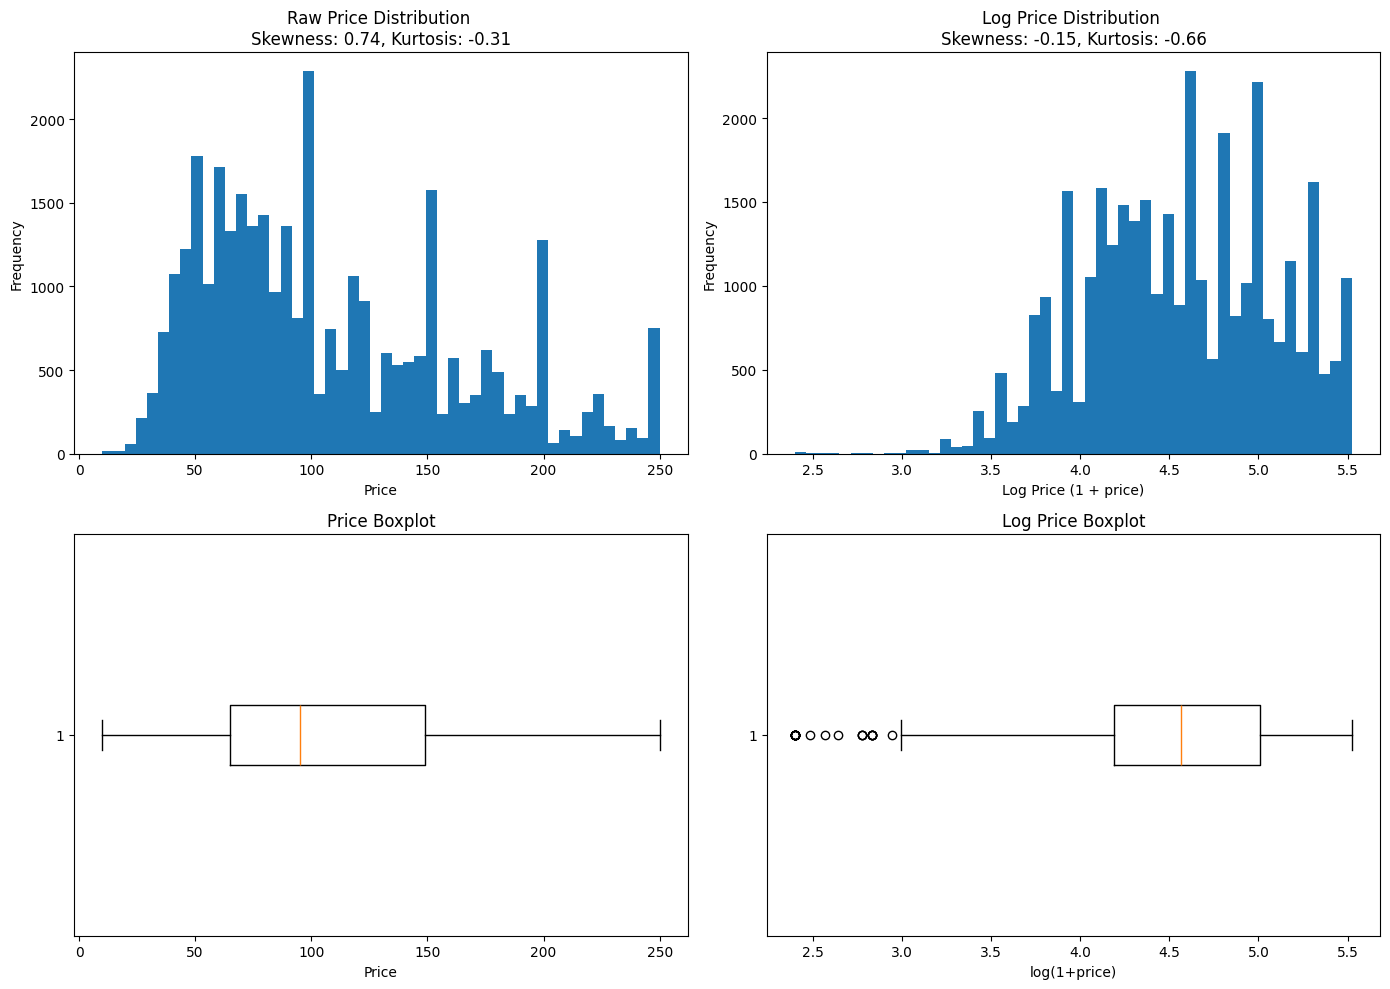

In [540]:
#Statistics Calculation
raw_skew= skew(df_quality_assessed["price"])
log_skew= skew(df_quality_assessed["log_price"])

raw_kurt= kurtosis(df_quality_assessed["price"])
log_kurt= kurtosis(df_quality_assessed["log_price"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#1.raw price histogram
axes[0,0].hist(df_quality_assessed["price"], bins=50)
axes[0,0].set_title(f"Raw Price Distribution \nSkewness: {raw_skew:.2f}, Kurtosis: {raw_kurt:.2f}")
axes[0,0].set_xlabel("Price")
axes[0,0].set_ylabel("Frequency")

#2.log price histogram
axes[0,1].hist(df_quality_assessed["log_price"], bins=50)
axes[0,1].set_title(f"Log Price Distribution \nSkewness: {log_skew:.2f}, Kurtosis: {log_kurt:.2f}")
axes[0,1].set_xlabel("Log Price (1 + price)")
axes[0,1].set_ylabel("Frequency")

#2.Raw price boxplot
axes[1,0].boxplot(df_quality_assessed["price"], vert=False)
axes[1,0].set_title("Price Boxplot")
axes[1,0].set_xlabel("Price")


#2.log price boxplot
axes[1,1].boxplot(df_quality_assessed["log_price"], vert=False)
axes[1,1].set_title("Log Price Boxplot")
axes[1,1].set_xlabel("log(1+price)")

plt.tight_layout()
plt.show()

In [541]:
df_quality_assessed=df_quality_assessed.drop(columns=["price_quality_flag", "segment_p99", "segment_p995","price_modified_z", "segment_p95", "segment_p935","segment_p905"], errors="ignore")
df_quality_assessed.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,0.38,2,355,5.420535
2,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,4.64,1,194,4.499810
3,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,0.10,1,0,4.394449
4,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200.0,3,74,0.59,1,129,5.303305
5,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60.0,45,49,0.40,1,0,4.110874


In [542]:
df_quality_assessed.shape

(33832, 12)

In [543]:
# -------------------------------------------------------------
# Step 13: Save the cleaned version to processed folder
# -------------------------------------------------------------
print("\n💾 Saving cleaned version to interim file (optional step)...")
df_quality_assessed.to_csv("../data/processed/AB_NYC_2019_quality_assessed.csv", index=False)
print("✅ Cleaned data saved to '../data/processed/AB_NYC_2019_quality_assessed.csv'")


💾 Saving cleaned version to interim file (optional step)...
✅ Cleaned data saved to '../data/processed/AB_NYC_2019_quality_assessed.csv'


In [544]:
# Next Step 
# Feature Engineering